# Preprocesamiento para Autoencoder - Dataset Multivariado H2V

## 🎯 Objetivo
Preparar los datos imputados para el entrenamiento del autoencoder:
1. Cargar datasets imputados (3 escenarios SSP)
2. Definir máscaras espaciales (tierra, H2V viable)
3. Normalización por tipo de variable
4. Manejo de variables temporales (agregación)
5. Splits espaciales train/val/test
6. Export de tensores procesados

## 📊 Input
- **Datasets:** `data/autoencoder_stack/autoencoder_stack_{ssp}_test_imputed.nc`
- **Variables:** 23 (22 originales + is_land)
- **Grid:** 1,008 celdas (24×42)
- **Periodo:** 86 años (2015-2100) para variables climáticas

## 📦 Output
- Tensores normalizados para train/val/test
- Metadatos de normalización (scalers)
- Máscaras espaciales guardadas
- Dataset consolidado listo para autoencoder

---

## 1️⃣ Imports y Configuración

In [28]:
    # Imports principales
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from copy import deepcopy
import warnings
warnings.filterwarnings('ignore')

# Sklearn para normalización
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.model_selection import train_test_split
import pickle

# Configuración de visualización
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (16, 10)
plt.rcParams['font.size'] = 10
%matplotlib inline

print("✓ Imports completados")
print(f"✓ NumPy version: {np.__version__}")
print(f"✓ Pandas version: {pd.__version__}")
print(f"✓ xarray version: {xr.__version__}")

✓ Imports completados
✓ NumPy version: 2.3.3
✓ Pandas version: 2.3.3
✓ xarray version: 2025.1.2


## 2️⃣ Rutas y Parámetros 

In [29]:
# Rutas
BASE_DIR = Path('/home/aninotna/magister/tesis/justh2_pipeline')
DATA_DIR = BASE_DIR / 'data' / 'autoencoder_stack'
OUT_DIR = BASE_DIR / 'data' / 'autoencoder_tensors'
PLOTS_DIR = BASE_DIR / 'plots' / 'autoencoder_prep'
OUT_DIR.mkdir(exist_ok=True, parents=True)
PLOTS_DIR.mkdir(exist_ok=True, parents=True)

# Parámetros
MODE = 'test'  # o 'full',
SCENARIOS = ['ssp245', 'ssp370', 'ssp585']
REFERENCE_SCENARIO = 'ssp245'  # Para calcular scalers
# Modo de ajuste de scalers: 'reference' (ajustar sobre REFERENCE_SCENARIO) o 'base' (ajustar sobre X_BASE concatenado)
SCALER_FIT_MODE = 'base'  # 'base' or 'reference'

# Configuración de preprocesamiento
CONFIG = {
    # Máscaras espaciales
    'use_mask': 'h2v_viable',  # Opciones: 'h2v_viable', 'land_only', 'full_grid'
    
    # Variables temporales
    'temporal_aggregation': 'decadal_stats',  # Opciones: 'decadal_mean', 'decadal_stats', 'trends', 'full_3d'
    
    # Splits
    'train_ratio': 0.70,
    'val_ratio': 0.15,
    'test_ratio': 0.15,
    'random_seed': 42,
    
    # Normalización
    'normalize': True,
    'scaler_type': {
        'continuous': 'standard',  # 'standard', 'robust', 'minmax'
        'fractions': 'minmax',
        'binary': None  # No normalizar variables binarias
    }
}

# Categorías de variables con tipo de normalización
VAR_NORMALIZATION = {
    # Calliope (continuas)
    'calliope_h2_prod_ton': 'standard',
    'calliope_lcoh_usd_kg': 'standard',
    'calliope_cap_pv_mw': None,  # Ya normalizado a [0,1] - NO normalizar
    'calliope_cap_electrolyzer_mw': 'standard',
    'calliope_cf_mean': None,  # Ya en [0,1] - NO normalizar
    
    # Clima (continuas)
    'climate_tmax_mean': 'standard',
    'climate_tmin_mean': 'standard',
    'climate_prcptot': 'standard',
    'climate_r10mm': 'standard',
    'climate_rx1day': 'standard',
    'climate_rx5day': 'standard',
    'climate_cdd': 'standard',
    'climate_sdii': 'standard',
    
    # Topografía (continuas)
    'topo_elevation': 'standard',
    'topo_slope': 'standard',
    
    # Uso de suelo (fracciones 0-1)
    'landuse_suitable_pv': 'minmax',
    'landuse_restricted': 'minmax',
    'landuse_agriculture': 'minmax',
    'landuse_urban_infra': 'minmax',
    'landuse_water_glacier': 'minmax',
    
    # Conflictos (continuas normalizadas)
    'conflict_density': 'robust',  # Puede tener outliers
    'conflict_proximity': None,  # Binario 0/1
}

print("=" * 80)
print("⚙️ CONFIGURACIÓN")
print("=" * 80)
print(f"\n📁 Directorios:")
print(f"   Data:   {DATA_DIR}")
print(f"   Output: {OUT_DIR}")
print(f"   Plots:  {PLOTS_DIR}")

print(f"\n🎬 Escenarios: {', '.join(SCENARIOS)}")
print(f"📌 Referencia:  {REFERENCE_SCENARIO}")
print(f"🔧 Modo:        {MODE}")

print(f"\n🎯 Configuración de Preprocesamiento:")
print(f"   Máscara espacial:        {CONFIG['use_mask']}")
print(f"   Agregación temporal:     {CONFIG['temporal_aggregation']}")
print(f"   Split train/val/test:    {CONFIG['train_ratio']:.0%}/{CONFIG['val_ratio']:.0%}/{CONFIG['test_ratio']:.0%}")
print(f"   Random seed:             {CONFIG['random_seed']}")
print(f"   Normalización:           {CONFIG['normalize']}")

print("=" * 80)

⚙️ CONFIGURACIÓN

📁 Directorios:
   Data:   /home/aninotna/magister/tesis/justh2_pipeline/data/autoencoder_stack
   Output: /home/aninotna/magister/tesis/justh2_pipeline/data/autoencoder_tensors
   Plots:  /home/aninotna/magister/tesis/justh2_pipeline/plots/autoencoder_prep

🎬 Escenarios: ssp245, ssp370, ssp585
📌 Referencia:  ssp245
🔧 Modo:        test

🎯 Configuración de Preprocesamiento:
   Máscara espacial:        h2v_viable
   Agregación temporal:     decadal_stats
   Split train/val/test:    70%/15%/15%
   Random seed:             42
   Normalización:           True


## 3️⃣ Cargar Datasets Imputados

In [30]:
print("=" * 80)
print("📂 CARGANDO DATASETS IMPUTADOS")
print("=" * 80)

datasets = {}

for scenario in SCENARIOS:
    DATA_DIR = BASE_DIR / 'data' / 'autoencoder_stack' / 'autoencoder_preprocessed'  # ← CORRECTO
    nc_file = DATA_DIR / f'{scenario}_imputed.nc'    
    if nc_file.exists():
        print(f"\n✓ Cargando {scenario.upper()}...")
        ds = xr.open_dataset(nc_file)
        datasets[scenario] = ds
        
        # Info
        file_size = nc_file.stat().st_size / (1024**2)
        print(f"  Archivo: {nc_file.name}")
        print(f"  Tamaño:  {file_size:.2f} MB")
        print(f"  Variables: {len(ds.data_vars)}")
        print(f"  Dimensiones: {dict(ds.dims)}")
        
        # Verificar imputación
        if 'imputation_applied' in ds.attrs:
            print(f"  Imputación: {ds.attrs['imputation_applied']}")
    else:
        print(f"\n⚠️ No encontrado: {nc_file.name}")
        print(f"   Verifica que el notebook 01_explore_stack.ipynb se ejecutó completamente")

print(f"\n{'='*80}")
print(f"✅ {len(datasets)}/{len(SCENARIOS)} escenarios cargados")
print('='*80)

# Dataset de referencia
if REFERENCE_SCENARIO in datasets:
    ds_ref = datasets[REFERENCE_SCENARIO]
    print(f"\n📌 Dataset de referencia: {REFERENCE_SCENARIO.upper()}")
    print(f"   Grid: {len(ds_ref.lat)} × {len(ds_ref.lon)} = {len(ds_ref.lat)*len(ds_ref.lon)} celdas")
    if 'year' in ds_ref.dims:
        print(f"   Años: {len(ds_ref.year)} ({ds_ref.year.values[0]}-{ds_ref.year.values[-1]})")
else:
    ds_ref = None
    print("\n⚠️ No se pudo cargar dataset de referencia")

📂 CARGANDO DATASETS IMPUTADOS

✓ Cargando SSP245...
  Archivo: ssp245_imputed.nc
  Tamaño:  1.36 MB
  Variables: 21
  Dimensiones: {'lat': 24, 'lon': 42, 'year': 86}
  Imputación: True

✓ Cargando SSP370...
  Archivo: ssp370_imputed.nc
  Tamaño:  1.37 MB
  Variables: 21
  Dimensiones: {'lat': 24, 'lon': 42, 'year': 86}
  Imputación: True

✓ Cargando SSP585...
  Archivo: ssp585_imputed.nc
  Tamaño:  1.37 MB
  Variables: 21
  Dimensiones: {'lat': 24, 'lon': 42, 'year': 86}
  Imputación: True

✅ 3/3 escenarios cargados

📌 Dataset de referencia: SSP245
   Grid: 24 × 42 = 1008 celdas
   Años: 86 (2015-2100)


## 4️⃣ Definir Máscaras Espaciales

🗺️ DEFINIENDO MÁSCARAS ESPACIALES
✅ Máscara recreada correctamente: shape = (24, 42)

✅ MÁSCARA SELECCIONADA: h2v_viable
   Celdas válidas: 661 (65.6%)
   Celdas filtradas: 347 (34.4%)

Generando visualización de máscaras...
✅ Guardado: /home/aninotna/magister/tesis/justh2_pipeline/plots/autoencoder_prep/spatial_masks_test.png
✅ Guardado: /home/aninotna/magister/tesis/justh2_pipeline/plots/autoencoder_prep/spatial_masks_test.png


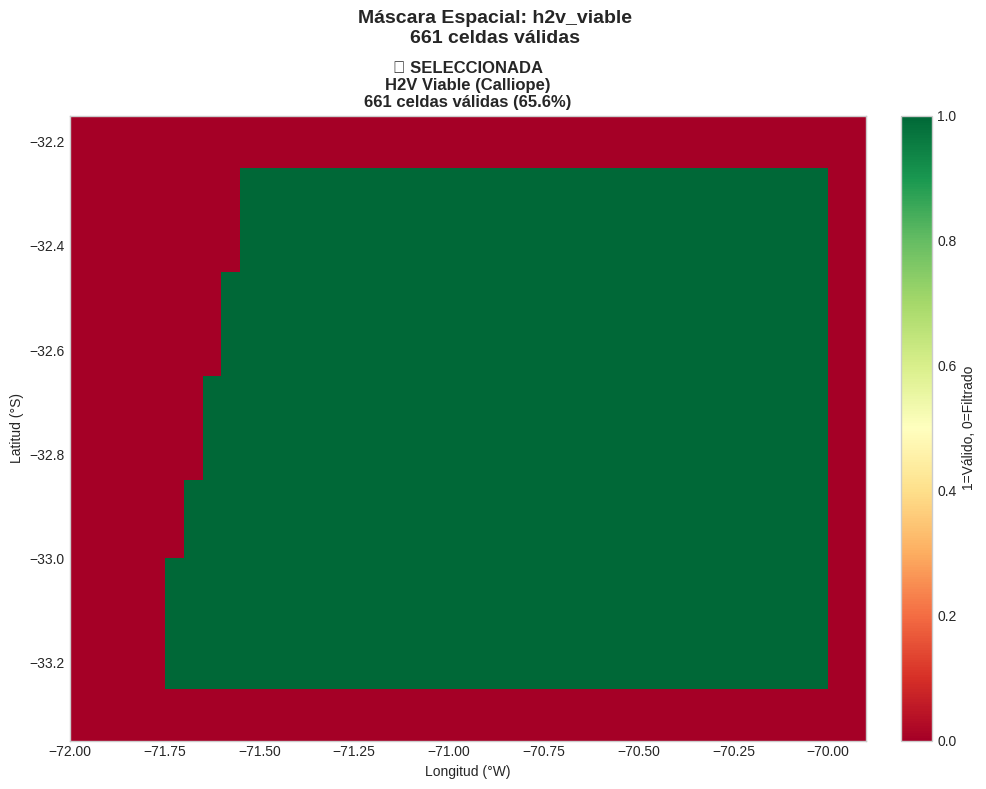

In [31]:
if ds_ref is not None:
    print("=" * 80)
    print("🗺️ DEFINIENDO MÁSCARAS ESPACIALES")
    print("=" * 80)
    
    # Máscaras disponibles
    masks = {}
    
    # FIX: Recrear h2v_mask correctamente manejando dimensión temporal
    h2v_var = ds_ref['calliope_h2_prod_ton']
    if 'year' in h2v_var.dims:
        h2v_data = h2v_var.isel(year=0).values  # Primer año
        print(f"💡 Variable temporal detectada: usando año {int(h2v_var.year.values[0])} para máscara")
    else:
        h2v_data = h2v_var.values

    h2v_mask = ~np.isnan(h2v_data)
    masks['h2v_viable'] = h2v_mask
    print(f"✅ Máscara recreada correctamente: shape = {h2v_mask.shape}")
    # Seleccionar máscara según configuración
    selected_mask_name = CONFIG['use_mask']
    if selected_mask_name == 'h2v_viable':
        selected_mask = masks['h2v_viable']
    elif selected_mask_name == 'land_only':
        selected_mask = masks['land']
    elif selected_mask_name == 'full_grid':
        selected_mask = masks['full_grid']
    else:
        selected_mask = masks['combined']
        selected_mask_name = 'combined'
    
    n_selected = selected_mask.sum()
    
    print(f"\n{'='*80}")
    print(f"✅ MÁSCARA SELECCIONADA: {selected_mask_name}")
    print(f"{'='*80}")
    print(f"   Celdas válidas: {n_selected} ({n_selected/selected_mask.size*100:.1f}%)")
    print(f"   Celdas filtradas: {selected_mask.size - n_selected} ({(1-n_selected/selected_mask.size)*100:.1f}%)")
    
    # Visualizar máscaras
    print("\nGenerando visualización de máscaras...")
    
    # CAMBIO: Usar 1x1 ya que solo hay 1 máscara
    fig, ax = plt.subplots(1, 1, figsize=(10, 8))
    
    mask_name = 'h2v_viable'
    label = 'H2V Viable (Calliope)'
    
    mask_data = masks[mask_name].astype(float)
    n_valid = masks[mask_name].sum()
    
    im = ax.pcolormesh(
        ds_ref.lon,
        ds_ref.lat,
        mask_data.reshape(len(ds_ref.lat), len(ds_ref.lon)),
        cmap='RdYlGn',
        vmin=0,
        vmax=1,
        shading='auto'
    )
    
    # Marcar máscara seleccionada
    title_prefix = "★ SELECCIONADA\n" if mask_name == selected_mask_name else ""
    ax.set_title(
        f'{title_prefix}{label}\n{n_valid} celdas válidas ({n_valid/mask_data.size*100:.1f}%)',
        fontsize=12, fontweight='bold'
    )
    ax.set_xlabel('Longitud (°W)', fontsize=10)
    ax.set_ylabel('Latitud (°S)', fontsize=10)
    ax.grid(True, alpha=0.3)
    
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='1=Válido, 0=Filtrado')
    
    plt.suptitle(
        f'Máscara Espacial: {selected_mask_name}\n{n_selected} celdas válidas',
        fontsize=14, fontweight='bold', y=0.98
    )
    plt.tight_layout()
    
    fig_path = PLOTS_DIR / f'spatial_masks_{MODE}.png'
    plt.savefig(fig_path, dpi=300, bbox_inches='tight')
    print(f"✅ Guardado: {fig_path}")
    
    plt.show()
    
    print("\n" + "=" * 80)
else:
    print("⚠️ No hay dataset de referencia")
    selected_mask = None


## 5️⃣ Manejo de Variables Temporales

In [32]:
if ds_ref is not None:
    print("=" * 80)
    print("📅 PROCESAMIENTO DE VARIABLES TEMPORALES")
    print("=" * 80)
    
    # Identificar variables temporales (con dimensión 'year')
    temporal_vars = [v for v in ds_ref.data_vars if 'year' in ds_ref[v].dims]
    static_vars = [v for v in ds_ref.data_vars if 'year' not in ds_ref[v].dims]
    
    print(f"\nVariables temporales: {len(temporal_vars)}")
    for var in temporal_vars:
        print(f"   • {var}: {ds_ref[var].shape}")
    
    print(f"\nVariables estáticas: {len(static_vars)}")
    for var in static_vars:
        print(f"   • {var}: {ds_ref[var].shape}")
    
    # Función de agregación según configuración
    agg_method = CONFIG['temporal_aggregation']
    
    print(f"\n{'='*80}")
    print(f"🔄 APLICANDO AGREGACIÓN: {agg_method}")
    print(f"{'='*80}")
    
    # Procesar cada escenario
    datasets_processed = {}
    
    for scenario, ds in datasets.items():
        print(f"\n📊 Procesando {scenario.upper()}...")
        
        # DEBUG: Verificar dimensiones antes de procesar
        print(f"   🔍 DEBUG: ds.year.shape = {ds.year.shape}")
        print(f"   🔍 DEBUG: ds.year.values = {ds.year.values[:5]}...{ds.year.values[-5:]}")
        
        ds_proc = xr.Dataset()
        
        # Copiar variables estáticas sin cambios
        for var in static_vars:
            ds_proc[var] = ds[var]
        
        # Procesar variables temporales
        if agg_method == 'decadal_mean':
            # Promedios por década
            print("   Calculando promedios decadales...")
            
            years = ds.year.values
            decades = np.arange(2020, 2101, 10)  # 2020-2029, 2030-2039, ..., 2090-2099
            n_decades = len(decades)
            
            for var in temporal_vars:
                print(f"      • {var}")
                var_data = ds[var].values  # shape: (n_years, lat, lon)
                
                # Crear array para décadas
                decadal_data = np.zeros((n_decades, var_data.shape[1], var_data.shape[2]))
                
                for i, decade_start in enumerate(decades):
                    decade_mask = (years >= decade_start) & (years < decade_start + 10)
                    if decade_mask.any():
                        decadal_data[i] = np.mean(var_data[decade_mask], axis=0)
                    else:
                        decadal_data[i] = np.nan
                
                # Agregar al dataset con nueva dimensión 'decade'
                ds_proc[var] = (('decade', 'lat', 'lon'), decadal_data)
            
            ds_proc = ds_proc.assign_coords(decade=decades)
            print(f"   ✓ {len(temporal_vars)} variables agregadas en {n_decades} décadas")
        
        elif agg_method == 'decadal_stats':
            # Estadísticos por década (mean, std, min, max)
            print("   Calculando estadísticos decadales (mean, std, min, max)...")
            
            years = ds.year.values
            decades = np.arange(2020, 2101, 10)
            n_decades = len(decades)
            
            print(f"   🔍 DEBUG: years tiene {len(years)} elementos")
            print(f"   🔍 DEBUG: decades = {decades}")
            
            for var in temporal_vars:
                print(f"      • {var}")
                var_data = ds[var].values
                
                # DEBUG: Verificar shape de var_data
                print(f"         🔍 DEBUG: var_data.shape = {var_data.shape}")
                print(f"         🔍 DEBUG: ds[var].dims = {ds[var].dims}")
                
                # VERIFICACIÓN: Asegurar que la primera dimensión es 'year'
                if ds[var].dims[0] != 'year':
                    print(f"         ⚠️ ERROR: Primera dimensión no es 'year', es '{ds[var].dims[0]}'")
                    print(f"         Intentando reordenar dimensiones...")
                    # Reordenar para que 'year' sea la primera dimensión
                    ds_var_reordered = ds[var].transpose('year', ...)
                    var_data = ds_var_reordered.values
                    print(f"         ✓ Reordenado: var_data.shape = {var_data.shape}")
                
                for stat_name in ['mean', 'std', 'min', 'max']:
                    stat_data = np.zeros((n_decades, var_data.shape[1], var_data.shape[2]))
                    
                    for i, decade_start in enumerate(decades):
                        decade_mask = (years >= decade_start) & (years < decade_start + 10)
                        
                        # DEBUG para el primer década
                        if i == 0:
                            print(f"         🔍 DEBUG década {decade_start}: decade_mask.sum() = {decade_mask.sum()}")
                        
                        if decade_mask.any():
                            decade_values = var_data[decade_mask]
                            if stat_name == 'mean':
                                stat_data[i] = np.mean(decade_values, axis=0)
                            elif stat_name == 'std':
                                stat_data[i] = np.std(decade_values, axis=0)
                            elif stat_name == 'min':
                                stat_data[i] = np.min(decade_values, axis=0)
                            elif stat_name == 'max':
                                stat_data[i] = np.max(decade_values, axis=0)
                        else:
                            stat_data[i] = np.nan
                    
                    # Nombre de variable: climate_tmax_mean_decadal_mean
                    new_var_name = f"{var}_decadal_{stat_name}"
                    ds_proc[new_var_name] = (('decade', 'lat', 'lon'), stat_data)
            
            ds_proc = ds_proc.assign_coords(decade=decades)
            print(f"   ✓ {len(temporal_vars) * 4} features creados (4 stats × {len(temporal_vars)} vars)")
        
        elif agg_method == 'trends':
            # Calcular tendencias temporales (pendiente lineal)
            print("   Calculando tendencias lineales...")
            
            years = ds.year.values
            
            for var in temporal_vars:
                print(f"      • {var}")
                var_data = ds[var].values  # (n_years, lat, lon)
                
                # DEBUG: Verificar shape
                print(f"         🔍 DEBUG: var_data.shape = {var_data.shape}")
                print(f"         🔍 DEBUG: ds[var].dims = {ds[var].dims}")
                
                # VERIFICACIÓN: Asegurar que la primera dimensión es 'year'
                if ds[var].dims[0] != 'year':
                    print(f"         ⚠️ ERROR: Primera dimensión no es 'year', es '{ds[var].dims[0]}'")
                    ds_var_reordered = ds[var].transpose('year', ...)
                    var_data = ds_var_reordered.values
                    print(f"         ✓ Reordenado: var_data.shape = {var_data.shape}")
                
                # Calcular pendiente para cada celda
                n_lat, n_lon = var_data.shape[1], var_data.shape[2]
                slope_data = np.zeros((n_lat, n_lon))
                intercept_data = np.zeros((n_lat, n_lon))
                
                for i in range(n_lat):
                    for j in range(n_lon):
                        cell_values = var_data[:, i, j]
                        if not np.isnan(cell_values).all():
                            # Regresión lineal simple
                            valid_mask = ~np.isnan(cell_values)
                            if valid_mask.sum() > 1:
                                x = years[valid_mask]
                                y = cell_values[valid_mask]
                                coeffs = np.polyfit(x, y, 1)
                                slope_data[i, j] = coeffs[0]  # pendiente
                                intercept_data[i, j] = coeffs[1]  # intercepto
                            else:
                                slope_data[i, j] = np.nan
                                intercept_data[i, j] = np.nan
                        else:
                            slope_data[i, j] = np.nan
                            intercept_data[i, j] = np.nan
                
                # Agregar tendencias
                ds_proc[f"{var}_trend_slope"] = (('lat', 'lon'), slope_data)
                ds_proc[f"{var}_trend_intercept"] = (('lat', 'lon'), intercept_data)
            
            print(f"   ✓ {len(temporal_vars) * 2} features creados (slope + intercept × {len(temporal_vars)} vars)")
        
        elif agg_method == 'full_3d':
            # Mantener dimensión temporal completa
            print("   Manteniendo dimensión temporal completa...")
            
            for var in temporal_vars:
                ds_proc[var] = ds[var]
            
            print(f"   ✓ {len(temporal_vars)} variables temporales preservadas")
        
        else:
            raise ValueError(f"Método de agregación desconocido: {agg_method}")
        
        # Copiar coordenadas
        ds_proc = ds_proc.assign_coords(lat=ds.lat, lon=ds.lon)
        
        # Guardar dataset procesado
        datasets_processed[scenario] = ds_proc
        
        print(f"   ✅ Dataset procesado: {len(ds_proc.data_vars)} variables")
    
    print(f"\n{'='*80}")
    print("✅ AGREGACIÓN TEMPORAL COMPLETADA")
    print(f"{'='*80}")
    
    # Actualizar referencia
    ds_ref = datasets_processed[REFERENCE_SCENARIO]
    
    print(f"\nVariables en dataset procesado:")
    print(f"   Total: {len(ds_ref.data_vars)}")
    if 'decade' in ds_ref.dims:
        print(f"   Dimensión temporal: decade ({len(ds_ref.decade)} períodos)")
    elif 'year' in ds_ref.dims:
        print(f"   Dimensión temporal: year ({len(ds_ref.year)} años)")
    else:
        print(f"   Solo variables estáticas")
    
    print("\n" + "=" * 80)
else:
    print("⚠️ No hay dataset de referencia")
    datasets_processed = None


📅 PROCESAMIENTO DE VARIABLES TEMPORALES

Variables temporales: 8
   • climate_tmax_mean: (86, 24, 42)
   • climate_tmin_mean: (86, 24, 42)
   • climate_prcptot: (86, 24, 42)
   • climate_r10mm: (86, 24, 42)
   • climate_rx1day: (86, 24, 42)
   • climate_rx5day: (86, 24, 42)
   • climate_cdd: (86, 24, 42)
   • climate_sdii: (86, 24, 42)

Variables estáticas: 13
   • calliope_h2_prod_ton: (24, 42)
   • calliope_lcoh_usd_kg: (24, 42)
   • calliope_cap_electrolyzer_mw: (24, 42)
   • calliope_cf_mean: (24, 42)
   • topo_slope: (24, 42)
   • topo_elevation: (24, 42)
   • landuse_suitable_pv: (24, 42)
   • landuse_restricted: (24, 42)
   • landuse_agriculture: (24, 42)
   • landuse_urban_infra: (24, 42)
   • landuse_water_glacier: (24, 42)
   • conflict_density: (24, 42)
   • conflict_proximity: (24, 42)

🔄 APLICANDO AGREGACIÓN: decadal_stats

📊 Procesando SSP245...
   🔍 DEBUG: ds.year.shape = (86,)
   🔍 DEBUG: ds.year.values = [2015 2016 2017 2018 2019]...[2096 2097 2098 2099 2100]
   Calcul

## 6️⃣ Crear Tensores de Datos (Aplicar Máscara)

In [33]:
if ds_ref is not None and selected_mask is not None:
    print("=" * 80)
    print("🔲 CREANDO TENSORES DE DATOS CON MÁSCARA")
    print("=" * 80)
    
    # Flatten spatial dimensions y aplicar máscara
    print(f"\nMáscara seleccionada: {selected_mask_name}")
    print(f"Celdas válidas: {n_selected}")
    
    # Para cada escenario, crear tensor de features
    tensors = {}
    
    for scenario, ds_proc in datasets_processed.items():
        print(f"\n📊 Procesando {scenario.upper()}...")
        
        # Lista de todas las variables (excluyendo coordenadas)
        all_vars = [v for v in ds_proc.data_vars]
        
        print(f"   Variables totales: {len(all_vars)}")
        
        # Crear array para almacenar features
        # Si hay dimensión temporal (decade), aplanar también
        feature_list = []
        feature_names = []
        
        for var in all_vars:
            var_data = ds_proc[var].values
            
            # Manejar diferentes dimensiones
            if var_data.ndim == 2:
                # Estática (lat, lon)
                flat_data = var_data.flatten()[selected_mask.flatten()]
                feature_list.append(flat_data)
                feature_names.append(var)
            
            elif var_data.ndim == 3:
                # Temporal (decade/year, lat, lon) o otra dim
                n_time = var_data.shape[0]
                for t in range(n_time):
                    flat_data = var_data[t].flatten()[selected_mask.flatten()]
                    feature_list.append(flat_data)
                    
                    # Nombre con índice temporal
                    if 'decade' in ds_proc[var].dims:
                        decade_val = ds_proc.decade.values[t]
                        feature_names.append(f"{var}_{int(decade_val)}")
                    elif 'year' in ds_proc[var].dims:
                        year_val = ds_proc.year.values[t]
                        feature_names.append(f"{var}_{int(year_val)}")
                    else:
                        feature_names.append(f"{var}_t{t}")
            
            else:
                print(f"   ⚠️ Variable {var} tiene dimensión inesperada: {var_data.shape}")
        
        # Stack features
        X = np.column_stack(feature_list)  # (n_cells, n_features)
        
        print(f"   Shape del tensor: {X.shape}")
        print(f"   Features: {len(feature_names)}")
        
        # Verificar NaNs
        n_nans = np.isnan(X).sum()
        if n_nans > 0:
            print(f"   ⚠️ NaNs detectados: {n_nans} ({n_nans/X.size*100:.3f}%)")
            
            # Identificar variables con NaNs
            nan_cols = np.isnan(X).any(axis=0)
            if nan_cols.any():
                print(f"   Features con NaNs:")
                for idx in np.where(nan_cols)[0]:
                    n_nan_in_col = np.isnan(X[:, idx]).sum()
                    print(f"      • {feature_names[idx]}: {n_nan_in_col}/{X.shape[0]} celdas")
        else:
            print(f"   ✅ Sin NaNs")
        
        # Guardar tensor y metadata
        tensors[scenario] = {
            'X': X,
            'feature_names': feature_names,
            'mask': selected_mask,
            'mask_name': selected_mask_name,
            'n_cells': n_selected,
            'n_features': len(feature_names)
        }
    
    print(f"\n{'='*80}")
    print("✅ TENSORES CREADOS PARA TODOS LOS ESCENARIOS")
    print(f"{'='*80}")
    
    # Resumen
    for scenario, tensor_data in tensors.items():
        X = tensor_data['X']
        print(f"\n{scenario.upper()}:")
        print(f"   Shape: {X.shape}")
        print(f"   Size: {X.nbytes / (1024**2):.2f} MB")
        print(f"   NaNs: {np.isnan(X).sum()} ({np.isnan(X).sum()/X.size*100:.3f}%)")
    
    print("\n" + "=" * 80)
else:
    print("⚠️ No hay dataset o máscara disponible")
    tensors = None

🔲 CREANDO TENSORES DE DATOS CON MÁSCARA

Máscara seleccionada: h2v_viable
Celdas válidas: 661

📊 Procesando SSP245...
   Variables totales: 45
   Shape del tensor: (661, 301)
   Features: 301
   ✅ Sin NaNs

📊 Procesando SSP370...
   Variables totales: 45
   Shape del tensor: (661, 301)
   Features: 301
   ✅ Sin NaNs

📊 Procesando SSP585...
   Variables totales: 45
   Shape del tensor: (661, 301)
   Features: 301
   ✅ Sin NaNs

✅ TENSORES CREADOS PARA TODOS LOS ESCENARIOS

SSP245:
   Shape: (661, 301)
   Size: 1.52 MB
   NaNs: 0 (0.000%)

SSP370:
   Shape: (661, 301)
   Size: 1.52 MB
   NaNs: 0 (0.000%)

SSP585:
   Shape: (661, 301)
   Size: 1.52 MB
   NaNs: 0 (0.000%)



## 📊 Cálculo de Desviaciones Estándar Inter-Décadas (Target)

In [34]:

# Agregar desviaciones estándar inter-décadas de las décadas target (2040, 2060, 2080)
if tensors is not None:
    print("=" * 80)
    print("📈 CALCULANDO STD INTER-DÉCADAS (TARGET: 2040, 2060, 2080)")
    print("=" * 80)
    
    TARGET_DECADES = [2040, 2060, 2080]
    print(f"\nDécadas target: {TARGET_DECADES}")
    
    tensors_with_std = {}
    
    for scenario, tensor_data in tensors.items():
        print(f"\n📊 {scenario.upper()}...")
        
        X_original = tensor_data['X']
        feature_names = tensor_data['feature_names']
        
        # Identificar variables base con features decadales
        # Patrón: var_decadal_stat_YYYY
        import re
        decadal_pattern = re.compile(r'^(.+)_decadal_(mean|std|min|max)_(\d{4})$')
        
        # Agrupar features por (base_var, stat_type)
        grouped_features = {}
        
        for idx, fname in enumerate(feature_names):
            match = decadal_pattern.match(fname)
            if match:
                base_var = match.group(1)
                stat_type = match.group(2)
                decade = int(match.group(3))
                
                key = (base_var, stat_type)
                if key not in grouped_features:
                    grouped_features[key] = []
                grouped_features[key].append((decade, idx))
        
        print(f"   Variables base con features decadales: {len(grouped_features)}")
        
        # Calcular std inter-décadas para cada grupo
        new_features = []
        new_feature_names = []
        
        for (base_var, stat_type), decade_indices in sorted(grouped_features.items()):
            # Filtrar solo décadas target
            target_indices = [(dec, idx) for dec, idx in decade_indices if dec in TARGET_DECADES]
            
            if len(target_indices) == len(TARGET_DECADES):
                # Tenemos todas las décadas target
                indices_only = [idx for _, idx in sorted(target_indices)]
                
                # Extraer valores de las 3 décadas (shape: n_cells × 3)
                values = X_original[:, indices_only]  # (n_cells, 3)
                
                # Calcular std a lo largo de las décadas (axis=1)
                std_inter_decades = np.std(values, axis=1)  # (n_cells,)
                
                new_features.append(std_inter_decades)
                new_feature_names.append(f"{base_var}_{stat_type}_std_T")
        
        print(f"   Nuevas features std_T creadas: {len(new_features)}")
        
        if new_features:
            # Concatenar nuevas features al tensor original
            new_features_array = np.column_stack(new_features)  # (n_cells, n_new_features)
            X_augmented = np.hstack([X_original, new_features_array])
            
            # Actualizar feature names
            feature_names_augmented = feature_names + new_feature_names
            
            # Crear tensor actualizado - COPIAR TODAS LAS CLAVES
            tensors_with_std[scenario] = {
                'X': X_augmented,
                'feature_names': feature_names_augmented,
                'n_features': len(feature_names_augmented)
            }
            
            # Copiar todas las demás claves del tensor original
            for key in tensor_data.keys():
                if key not in ['X', 'feature_names', 'n_features']:
                    tensors_with_std[scenario][key] = tensor_data[key]
            
            print(f"   Shape original: {X_original.shape}")
            print(f"   Shape aumentado: {X_augmented.shape}")
            print(f"   Features totales: {len(feature_names_augmented)}")
            
            # Mostrar algunas de las nuevas features
            print(f"\n   📋 Primeras 10 nuevas features std_T:")
            for fname in new_feature_names[:10]:
                print(f"      • {fname}")
            if len(new_feature_names) > 10:
                print(f"      ... y {len(new_feature_names) - 10} más")
        else:
            # Sin nuevas features, mantener original
            tensors_with_std[scenario] = tensor_data
            print(f"   ⚠️ No se crearon nuevas features (verificar décadas disponibles)")
    
    # Reemplazar tensors con versión aumentada
    tensors = tensors_with_std
    
    print(f"\n{'='*80}")
    print("✅ STD INTER-DÉCADAS AGREGADAS")
    print(f"{'='*80}")
    
    # Resumen final
    print(f"\n📊 Resumen de tensores actualizados:")
    for scenario, tensor_data in tensors.items():
        X = tensor_data['X']
        print(f"\n   {scenario.upper()}:")
        print(f"      Shape: {X.shape}")
        print(f"      Features: {tensor_data['n_features']}")
        print(f"      Size: {X.nbytes / (1024**2):.2f} MB")
    
    print("\n" + "=" * 80)
else:
    print("⚠️ No hay tensores disponibles")


📈 CALCULANDO STD INTER-DÉCADAS (TARGET: 2040, 2060, 2080)

Décadas target: [2040, 2060, 2080]

📊 SSP245...
   Variables base con features decadales: 32
   Nuevas features std_T creadas: 32
   Shape original: (661, 301)
   Shape aumentado: (661, 333)
   Features totales: 333

   📋 Primeras 10 nuevas features std_T:
      • climate_cdd_max_std_T
      • climate_cdd_mean_std_T
      • climate_cdd_min_std_T
      • climate_cdd_std_std_T
      • climate_prcptot_max_std_T
      • climate_prcptot_mean_std_T
      • climate_prcptot_min_std_T
      • climate_prcptot_std_std_T
      • climate_r10mm_max_std_T
      • climate_r10mm_mean_std_T
      ... y 22 más

📊 SSP370...
   Variables base con features decadales: 32
   Nuevas features std_T creadas: 32
   Shape original: (661, 301)
   Shape aumentado: (661, 333)
   Features totales: 333

   📋 Primeras 10 nuevas features std_T:
      • climate_cdd_max_std_T
      • climate_cdd_mean_std_T
      • climate_cdd_min_std_T
      • climate_cdd_std_std_T

## 7️⃣ Normalización de Features

## 🧹 Limpieza de Features Problemáticas

### Estrategia de Limpieza y Normalización

**Paso 1: Filtrado de Features Problemáticas** 🧹
- Remover variables **completamente constantes** (std < 1e-10)
- Remover todas las variables `*_std_2100` (década con 1 solo año)

**Paso 2: Normalización Inteligente** 🎨
- **StandardScaler** (μ=0, σ=1): Variables con buena varianza (clima, producción H2, topografía)
- **RobustScaler** (mediana, IQR): Variables casi-constantes (STDs decadales, LCOH, capacidad)
- **None**: Variables ya normalizadas (fracciones de land use, densidad de conflictos)

**Ventajas:**
- RobustScaler es más robusto a outliers y baja varianza
- Evita colapsos de distribución en variables casi-constantes
- Preserva información de variables con pequeñas variaciones

In [35]:
# Filtrar features constantes y casi-constantes antes de normalización
if tensors is not None:
    print("=" * 80)
    print("🧹 FILTRADO DE FEATURES PROBLEMÁTICAS")
    print("=" * 80)
    
    # Analizar todos los escenarios
    tensors_filtered = {}
    
    for scenario in SCENARIOS:
        if scenario not in tensors:
            continue
        
        tensor_data = tensors[scenario]
        X_original = tensor_data['X']
        feature_names = tensor_data['feature_names']
        
        print(f"\n{scenario.upper()}:")
        print(f"   Features originales: {len(feature_names)}")
        
        # Identificar features a remover
        features_to_remove = []
        features_to_keep_indices = []
        
        for i, fname in enumerate(feature_names):
            col_data = X_original[:, i]
            col_std = np.nanstd(col_data)
            
            # Criterios de remoción
            is_constant = col_std < 1e-10  # Completamente constante
            is_2100_std = '_std_2100' in fname  # Todas las STD de 2100 son 0
            
            if is_constant or is_2100_std:
                features_to_remove.append(fname)
            else:
                features_to_keep_indices.append(i)
        
        # Filtrar features
        X_filtered = X_original[:, features_to_keep_indices]
        feature_names_filtered = [feature_names[i] for i in features_to_keep_indices]
        
        # Crear tensor filtrado - PRESERVAR TODAS LAS CLAVES ORIGINALES
        tensors_filtered[scenario] = {
            'X': X_filtered,
            'feature_names': feature_names_filtered,
            'n_cells': tensor_data['n_cells'],
            'n_features': len(feature_names_filtered),  # Actualizar número de features
            'removed_features': features_to_remove
        }
        
        # Copiar otras claves que puedan existir (mask, mask_name, etc.)
        for key in tensor_data.keys():
            if key not in ['X', 'feature_names', 'n_cells', 'n_features']:
                tensors_filtered[scenario][key] = tensor_data[key]
        
        print(f"   Features removidas: {len(features_to_remove)}")
        print(f"   Features finales: {len(feature_names_filtered)}")
        
        if len(features_to_remove) > 0:
            print(f"\n   📋 Features removidas (primeras 10):")
            for fname in features_to_remove[:10]:
                print(f"      • {fname}")
            if len(features_to_remove) > 10:
                print(f"      ... y {len(features_to_remove)-10} más")
    
    # Reemplazar tensors con versión filtrada
    tensors = tensors_filtered
    
    print(f"\n{'='*80}")
    print("✅ FILTRADO COMPLETADO")
    print("="*80)
    print(f"\nTensores actualizados para {len(tensors)} escenarios")
else:
    print("⚠️ No hay tensores disponibles para filtrar")

🧹 FILTRADO DE FEATURES PROBLEMÁTICAS

SSP245:
   Features originales: 333
   Features removidas: 8
   Features finales: 325

   📋 Features removidas (primeras 10):
      • climate_tmax_mean_decadal_std_2100
      • climate_tmin_mean_decadal_std_2100
      • climate_prcptot_decadal_std_2100
      • climate_r10mm_decadal_std_2100
      • climate_rx1day_decadal_std_2100
      • climate_rx5day_decadal_std_2100
      • climate_cdd_decadal_std_2100
      • climate_sdii_decadal_std_2100

SSP370:
   Features originales: 333
   Features removidas: 8
   Features finales: 325

   📋 Features removidas (primeras 10):
      • climate_tmax_mean_decadal_std_2100
      • climate_tmin_mean_decadal_std_2100
      • climate_prcptot_decadal_std_2100
      • climate_r10mm_decadal_std_2100
      • climate_rx1day_decadal_std_2100
      • climate_rx5day_decadal_std_2100
      • climate_cdd_decadal_std_2100
      • climate_sdii_decadal_std_2100

SSP585:
   Features originales: 333
   Features removidas: 8
   Fe

## 🎨 Actualización de Configuración de Normalización

In [36]:
# Actualizar VAR_NORMALIZATION para usar RobustScaler en variables casi-constantes
if tensors is not None:
    print("=" * 80)
    print("🎨 CONFIGURACIÓN DE NORMALIZACIÓN MEJORADA")
    print("=" * 80)
    
    # Obtener feature names del escenario de referencia
    ref_tensor = tensors[REFERENCE_SCENARIO]
    feature_names = ref_tensor['feature_names']
    X_ref = ref_tensor['X']
    
    print(f"\nAnalizando {len(feature_names)} features...")
    
    # Actualizar VAR_NORMALIZATION con lógica mejorada
    VAR_NORMALIZATION_UPDATED = {}
    
    # Categorías para RobustScaler (variables con baja varianza natural)
    robust_patterns = [
        '_std_',  # Desviaciones estándar decadales (baja varianza)
        'calliope_lcoh',  # LCOH es casi constante espacialmente
        'calliope_cap_electrolyzer',  # Capacidad casi constante
    ]
    
    # Categorías para StandardScaler (mayoría de variables)
    standard_categories = [
        'climate_',
        'calliope_h2_prod',
        'calliope_cf_mean',
        'topo_',
        'landuse_',
        'conflict_',
    ]
    
    # Clasificar cada feature
    standard_features = []
    robust_features = []
    minmax_features = []
    none_features = []
    
    for i, feat in enumerate(feature_names):
        col_data = X_ref[:, i]
        col_std = np.nanstd(col_data)
        
        # Detectar si es casi-constante (usar Robust)
        is_almost_constant = col_std < 0.01
        matches_robust_pattern = any(pattern in feat for pattern in robust_patterns)
        
        if is_almost_constant or matches_robust_pattern:
            robust_features.append(feat)
            # Extraer base variable
            if '_decadal_' in feat:
                base_var = feat.split('_decadal_')[0]
            else:
                base_var = feat
            VAR_NORMALIZATION_UPDATED[base_var] = 'robust'
        
        # Máscaras binarias (MinMax o None)
        elif feat.startswith('landuse_') or feat.startswith('conflict_'):
            # Landuse y conflict ya están normalizados (0-1 o fracciones)
            none_features.append(feat)
            base_var = feat.split('_decadal_')[0] if '_decadal_' in feat else feat
            VAR_NORMALIZATION_UPDATED[base_var] = None
        
        # Resto: StandardScaler
        else:
            standard_features.append(feat)
            if '_decadal_' in feat:
                base_var = feat.split('_decadal_')[0]
            else:
                base_var = feat
            VAR_NORMALIZATION_UPDATED[base_var] = 'standard'
    
    print(f"\n📊 Distribución de normalización:")
    print(f"   • StandardScaler: {len(standard_features)} features")
    print(f"   • RobustScaler:   {len(robust_features)} features")
    print(f"   • MinMaxScaler:   {len(minmax_features)} features")
    print(f"   • None (sin normalizar): {len(none_features)} features")
    
    print(f"\n🔍 Ejemplos de RobustScaler (casi-constantes):")
    for feat in robust_features[:10]:
        col_std = np.nanstd(X_ref[:, feature_names.index(feat)])
        print(f"   • {feat[:60]}: std={col_std:.4e}")
    if len(robust_features) > 10:
        print(f"   ... y {len(robust_features)-10} más")
    
    # Actualizar configuración global
    VAR_NORMALIZATION = VAR_NORMALIZATION_UPDATED
    
    print(f"\n{'='*80}")
    print("✅ CONFIGURACIÓN ACTUALIZADA")
    print("="*80)
    print(f"\nVAR_NORMALIZATION ahora tiene {len(VAR_NORMALIZATION)} entradas")
    print(f"RobustScaler será usado para variables con baja varianza")
else:
    print("⚠️ No hay tensores disponibles")

🎨 CONFIGURACIÓN DE NORMALIZACIÓN MEJORADA

Analizando 325 features...

📊 Distribución de normalización:
   • StandardScaler: 220 features
   • RobustScaler:   98 features
   • MinMaxScaler:   0 features
   • None (sin normalizar): 7 features

🔍 Ejemplos de RobustScaler (casi-constantes):
   • calliope_lcoh_usd_kg: std=8.6157e+01
   • calliope_cap_electrolyzer_mw: std=7.8591e-02
   • climate_tmax_mean_decadal_std_2020: std=5.0346e-02
   • climate_tmax_mean_decadal_std_2030: std=8.8364e-02
   • climate_tmax_mean_decadal_std_2040: std=6.8998e-02
   • climate_tmax_mean_decadal_std_2050: std=8.2341e-02
   • climate_tmax_mean_decadal_std_2060: std=7.6740e-02
   • climate_tmax_mean_decadal_std_2070: std=1.1347e-01
   • climate_tmax_mean_decadal_std_2080: std=2.9410e-02
   • climate_tmax_mean_decadal_std_2090: std=1.1084e-01
   ... y 88 más

✅ CONFIGURACIÓN ACTUALIZADA

VAR_NORMALIZATION ahora tiene 53 entradas
RobustScaler será usado para variables con baja varianza


## 7️⃣ Normalización de Features (con Scalers Apropiados)

In [37]:
if tensors is not None and VAR_NORMALIZATION is not None:
    print("=" * 80)
    print("🎨 NORMALIZACIÓN DE FEATURES")
    print("=" * 80)
    
    # Usar escenario de referencia para entrenar scalers
    ref_tensor = tensors[REFERENCE_SCENARIO]
    X_ref = ref_tensor['X']
    feature_names = ref_tensor['feature_names']
    
    print(f"\nEscenario de referencia: {REFERENCE_SCENARIO}")
    print(f"Shape: {X_ref.shape}")
    print(f"Features: {len(feature_names)}")
    
    # Mapear cada feature a su tipo de scaler
    print(f"\n📊 Identificando tipo de normalización por variable...")
    
    # Identificar la variable base de cada feature (antes del sufijo temporal)
    feature_scaler_map = {}
    for feat in feature_names:
        # Extraer variable base (antes de _decadal_, _trend_, etc.)
        if '_decadal_' in feat:
            base_var = feat.split('_decadal_')[0]
        elif '_trend_' in feat:
            base_var = feat.split('_trend_')[0]
        elif feat[-5:].isdigit():  # Termina en año (e.g., _2020)
            parts = feat.split('_')
            base_var = '_'.join(parts[:-1])
        else:
            base_var = feat
        
        # Buscar en VAR_NORMALIZATION
        scaler_type = VAR_NORMALIZATION.get(base_var, 'standard')
        feature_scaler_map[feat] = scaler_type
    
    # Contar por tipo
    scaler_counts = {}
    sorted_items = sorted(scaler_counts.items(), key=lambda x: (x[0] is None, x[0] or ''))
    for stype, count in sorted_items:
        scaler_counts[stype] = scaler_counts.get(stype, 0) + 1
    
    print(f"\n🔍 Features por tipo de scaler:")
    for stype, count in sorted(scaler_counts.items()):
        print(f"   • {stype if stype else 'None (sin normalizar)'}: {count} features")
    
    # Crear scalers
    scalers = {}
    
    # 1. StandardScaler (μ=0, σ=1)
    standard_features = [i for i, feat in enumerate(feature_names) 
                         if feature_scaler_map[feat] == 'standard']
    if len(standard_features) > 0:
        print(f"\n📐 StandardScaler (μ=0, σ=1):")
        print(f"   Features: {len(standard_features)}")
        scaler_std = StandardScaler()
        scaler_std.fit(X_ref[:, standard_features])
        scalers['standard'] = {
            'scaler': scaler_std,
            'feature_indices': standard_features,
            'feature_names': [feature_names[i] for i in standard_features]
        }
        print(f"   ✓ Scaler entrenado")
    
    # 2. MinMaxScaler (0-1)
    minmax_features = [i for i, feat in enumerate(feature_names) 
                       if feature_scaler_map[feat] == 'minmax']
    if len(minmax_features) > 0:
        print(f"\n� MinMaxScaler (0-1):")
        print(f"   Features: {len(minmax_features)}")
        scaler_mm = MinMaxScaler()
        scaler_mm.fit(X_ref[:, minmax_features])
        scalers['minmax'] = {
            'scaler': scaler_mm,
            'feature_indices': minmax_features,
            'feature_names': [feature_names[i] for i in minmax_features]
        }
        print(f"   ✓ Scaler entrenado")
    
    # 3. RobustScaler (resistente a outliers)
    robust_features = [i for i, feat in enumerate(feature_names) 
                       if feature_scaler_map[feat] == 'robust']
    if len(robust_features) > 0:
        print(f"\n🛡️ RobustScaler (mediana/IQR):")
        print(f"   Features: {len(robust_features)}")
        scaler_rob = RobustScaler()
        scaler_rob.fit(X_ref[:, robust_features])
        scalers['robust'] = {
            'scaler': scaler_rob,
            'feature_indices': robust_features,
            'feature_names': [feature_names[i] for i in robust_features]
        }
        print(f"   ✓ Scaler entrenado")
    
    # 4. Sin normalizar (None)
    none_features = [i for i, feat in enumerate(feature_names) 
                     if feature_scaler_map[feat] is None or feature_scaler_map[feat] == 'none']
    if len(none_features) > 0:
        print(f"\n⚪ Sin normalizar:")
        print(f"   Features: {len(none_features)}")
        print(f"   (Variables binarias o máscaras)")
    
    # Aplicar normalización a todos los escenarios
    print(f"\n{'='*80}")
    print("�🔄 APLICANDO NORMALIZACIÓN A TODOS LOS ESCENARIOS")
    print(f"{'='*80}")
    
    tensors_normalized = {}
    
    for scenario, tensor_data in tensors.items():
        print(f"\n📊 {scenario.upper()}...")
        X_original = tensor_data['X'].copy()
        X_norm = X_original.copy()
        
        # Aplicar cada scaler
        for stype, scaler_info in scalers.items():
            indices = scaler_info['feature_indices']
            scaler_obj = scaler_info['scaler']
            
            X_norm[:, indices] = scaler_obj.transform(X_original[:, indices])
            print(f"   ✓ {stype}: {len(indices)} features normalizados")
        
        # Guardar tensor normalizado
        tensors_normalized[scenario] = {
            'X': X_norm,
            'X_original': X_original,
            'feature_names': tensor_data['feature_names'],
            'mask': tensor_data['mask'],
            'mask_name': tensor_data['mask_name'],
            'n_cells': tensor_data['n_cells'],
            'n_features': tensor_data['n_features']
        }
        
        # Verificar
        n_nans = np.isnan(X_norm).sum()
        print(f"   NaNs después de normalización: {n_nans} ({n_nans/X_norm.size*100:.4f}%)")
    
    print(f"\n{'='*80}")
    print("✅ NORMALIZACIÓN COMPLETADA")
    print(f"{'='*80}")
    
    # Estadísticas de normalización (para StandardScaler)
    if 'standard' in scalers:
        print(f"\n📊 Verificación StandardScaler (primeras 5 features):")
        std_indices = scalers['standard']['feature_indices'][:5]
        std_names = [feature_names[i] for i in std_indices]
        
        for idx, name in zip(std_indices, std_names):
            X_norm_col = tensors_normalized[REFERENCE_SCENARIO]['X'][:, idx]
            print(f"   {name[:40]:40s}: μ={X_norm_col.mean():.4f}, σ={X_norm_col.std():.4f}")
    
    print("\n" + "=" * 80)
else:
    print("⚠️ No hay tensores o configuración de normalización disponible")
    tensors_normalized = None
    scalers = None

🎨 NORMALIZACIÓN DE FEATURES

Escenario de referencia: ssp245
Shape: (661, 325)
Features: 325

📊 Identificando tipo de normalización por variable...

🔍 Features por tipo de scaler:

📐 StandardScaler (μ=0, σ=1):
   Features: 284
   ✓ Scaler entrenado

🛡️ RobustScaler (mediana/IQR):
   Features: 34
   ✓ Scaler entrenado

⚪ Sin normalizar:
   Features: 7
   (Variables binarias o máscaras)

�🔄 APLICANDO NORMALIZACIÓN A TODOS LOS ESCENARIOS

📊 SSP245...
   ✓ standard: 284 features normalizados
   ✓ robust: 34 features normalizados
   NaNs después de normalización: 0 (0.0000%)

📊 SSP370...
   ✓ standard: 284 features normalizados
   ✓ robust: 34 features normalizados
   NaNs después de normalización: 0 (0.0000%)

📊 SSP585...
   ✓ standard: 284 features normalizados
   ✓ robust: 34 features normalizados
   NaNs después de normalización: 0 (0.0000%)

✅ NORMALIZACIÓN COMPLETADA

📊 Verificación StandardScaler (primeras 5 features):
   calliope_h2_prod_ton                    : μ=-0.0000, σ=1.0000


## 8️⃣ Splits Espaciales (Train/Val/Test)

SPLITS ESPACIALES (TRAIN / VAL / TEST)

Configuración de splits:
   Train: 70.0%
   Val:   15.0%
   Test:  15.0%
   Random seed: 42

🔢 Total de celdas: 661

Splits creados:
   Train: 462 celdas (69.9%)
   Val:   99 celdas (15.0%)
   Test:  100 celdas (15.1%)

Splits aplicados a todos los escenarios

Visualizando distribución espacial...
   ✓ Figura guardada: splits_spatial_distribution_test.png
   ✓ Figura guardada: splits_spatial_distribution_test.png


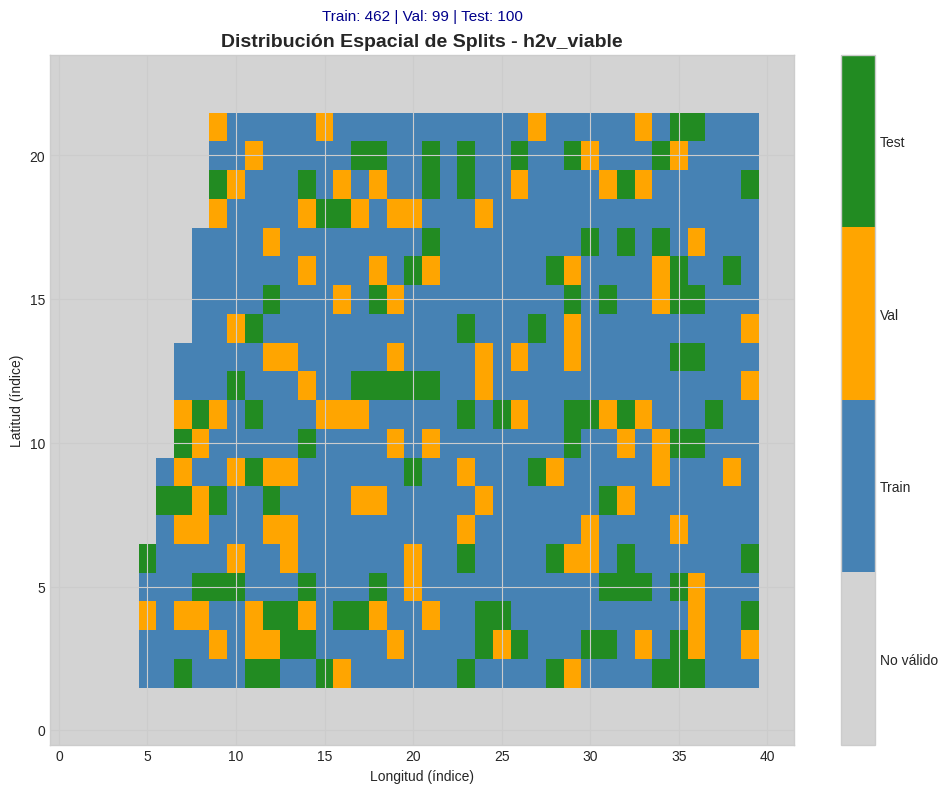


SPLITS ESPACIALES COMPLETADOS



In [38]:
if tensors_normalized is not None and CONFIG is not None:
    print("=" * 80)
    print("SPLITS ESPACIALES (TRAIN / VAL / TEST)")
    print("=" * 80)
    
    # Obtener parámetros de split
    train_ratio = CONFIG['train_ratio']
    val_ratio = CONFIG['val_ratio']
    test_ratio = CONFIG['test_ratio']
    random_seed = CONFIG['random_seed']
    
    # Verificar que sumen 1.0
    total_ratio = train_ratio + val_ratio + test_ratio
    if not np.isclose(total_ratio, 1.0):
        print(f"Ratios no suman 1.0: {total_ratio:.3f}")
        print(f"   Ajustando ratios proporcionalmente...")
        train_ratio /= total_ratio
        val_ratio /= total_ratio
        test_ratio /= total_ratio
    
    print(f"\nConfiguración de splits:")
    print(f"   Train: {train_ratio*100:.1f}%")
    print(f"   Val:   {val_ratio*100:.1f}%")
    print(f"   Test:  {test_ratio*100:.1f}%")
    print(f"   Random seed: {random_seed}")
    
    # Usar escenario de referencia para crear splits
    ref_tensor = tensors_normalized[REFERENCE_SCENARIO]
    n_cells = ref_tensor['n_cells']
    
    print(f"\n🔢 Total de celdas: {n_cells}")
    
    # Crear índices para split
    indices = np.arange(n_cells)
    np.random.seed(random_seed)
    
    # Split en dos pasos: train vs (val+test), luego val vs test
    train_idx, test_val_idx = train_test_split(
        indices, 
        test_size=(val_ratio + test_ratio), 
        random_state=random_seed
    )
    
    # Split val vs test (proporción relativa)
    val_ratio_relative = val_ratio / (val_ratio + test_ratio)
    val_idx, test_idx = train_test_split(
        test_val_idx,
        test_size=(1 - val_ratio_relative),
        random_state=random_seed
    )
    
    print(f"\nSplits creados:")
    print(f"   Train: {len(train_idx)} celdas ({len(train_idx)/n_cells*100:.1f}%)")
    print(f"   Val:   {len(val_idx)} celdas ({len(val_idx)/n_cells*100:.1f}%)")
    print(f"   Test:  {len(test_idx)} celdas ({len(test_idx)/n_cells*100:.1f}%)")
    
    # Aplicar splits a todos los escenarios
    splits = {}
    
    for scenario, tensor_data in tensors_normalized.items():
        X = tensor_data['X']
        
        splits[scenario] = {
            'X_train': X[train_idx],
            'X_val': X[val_idx],
            'X_test': X[test_idx],
            'train_idx': train_idx,
            'val_idx': val_idx,
            'test_idx': test_idx,
            'feature_names': tensor_data['feature_names'],
            'mask': tensor_data['mask'],
            'mask_name': tensor_data['mask_name']
        }
    
    print(f"\nSplits aplicados a todos los escenarios")
    
    # Visualizar distribución espacial de splits
    print(f"\nVisualizando distribución espacial...")
    
    # Crear mapa de splits
    split_map = np.full(selected_mask.shape, -1.0)  # -1 para celdas no seleccionadas
    
    # Obtener coordenadas planas de celdas válidas
    flat_indices = np.where(selected_mask.flatten())[0]
    
    # Asignar valores de split
    split_map.flat[flat_indices[train_idx]] = 0  # Train
    split_map.flat[flat_indices[val_idx]] = 1    # Val
    split_map.flat[flat_indices[test_idx]] = 2   # Test
    
    # Plotear
    fig, ax = plt.subplots(1, 1, figsize=(10, 8))
    
    # Colormap personalizado
    from matplotlib.colors import ListedColormap, BoundaryNorm
    colors = ['lightgray', 'steelblue', 'orange', 'forestgreen']
    cmap = ListedColormap(colors)
    bounds = [-1.5, -0.5, 0.5, 1.5, 2.5]
    norm = BoundaryNorm(bounds, cmap.N)
    
    im = ax.imshow(split_map, cmap=cmap, norm=norm, origin='lower', aspect='auto')
    
    # Colorbar con labels
    cbar = plt.colorbar(im, ax=ax, ticks=[-1, 0, 1, 2])
    cbar.ax.set_yticklabels(['No válido', 'Train', 'Val', 'Test'])
    
    ax.set_title(f'Distribución Espacial de Splits - {selected_mask_name}', 
                 fontsize=14, fontweight='bold')
    ax.set_xlabel('Longitud (índice)')
    ax.set_ylabel('Latitud (índice)')
    
    # Añadir conteo en el título
    title_prefix = f"Train: {len(train_idx)} | Val: {len(val_idx)} | Test: {len(test_idx)}"
    ax.text(0.5, 1.05, title_prefix, transform=ax.transAxes,
            ha='center', fontsize=11, color='darkblue')
    
    plt.tight_layout()
    
    # Guardar figura
    fig_path = PLOTS_DIR / f'splits_spatial_distribution_{MODE}.png'
    plt.savefig(fig_path, dpi=150, bbox_inches='tight')
    print(f"   ✓ Figura guardada: {fig_path.name}")
    
    plt.show()
    
    print(f"\n{'='*80}")
    print("SPLITS ESPACIALES COMPLETADOS")
    print(f"{'='*80}\n")

else:
    print("No hay tensores normalizados o configuración disponible")
    splits = None

## 🔍 DIAGNÓSTICO: Verificación de Datos Originales (Pre-Normalización)

In [39]:
print("DIAGNÓSTICO PRE-NORMALIZACIÓN", tensors)

DIAGNÓSTICO PRE-NORMALIZACIÓN {'ssp245': {'X': array([[5.29660596e+03, 1.51478333e+03, 1.69481897e+00, ...,
        4.45028965e-01, 5.09596586e-01, 4.41177668e-02],
       [5.42787500e+03, 1.48378613e+03, 1.74004829e+00, ...,
        4.45100268e-01, 5.13039377e-01, 4.52000113e-02],
       [5.55914404e+03, 1.45278894e+03, 1.78527749e+00, ...,
        4.45178626e-01, 5.16494612e-01, 4.63029063e-02],
       ...,
       [6.26749365e+03, 1.31247363e+03, 1.98667991e+00, ...,
        4.81954191e-01, 4.70091824e-01, 6.87257701e-02],
       [6.08647998e+03, 1.35028467e+03, 1.96743119e+00, ...,
        4.83409864e-01, 4.65017924e-01, 6.76543199e-02],
       [5.90546582e+03, 1.38809570e+03, 1.94818234e+00, ...,
        4.84869582e-01, 4.59946345e-01, 6.65213141e-02]], shape=(661, 325)), 'feature_names': ['calliope_h2_prod_ton', 'calliope_lcoh_usd_kg', 'calliope_cap_electrolyzer_mw', 'calliope_cf_mean', 'topo_slope', 'topo_elevation', 'landuse_suitable_pv', 'landuse_restricted', 'landuse_agricultu

In [40]:
# Diagnóstico detallado de features antes de normalización
import time

if tensors is not None and VAR_NORMALIZATION is not None:
    print("=" * 80)
    print("🔍 DIAGNÓSTICO PRE-NORMALIZACIÓN")
    print("=" * 80)
    
    # Usar tensores del escenario de referencia
    ref_tensor = tensors[REFERENCE_SCENARIO]
    X_ref = ref_tensor['X']
    feature_names = ref_tensor['feature_names']
    
    print(f"\nEscenario de referencia: {REFERENCE_SCENARIO}")
    print(f"Shape: {X_ref.shape}")
    print(f"Features: {len(feature_names)}")
    
    # Mapear cada feature a su tipo de scaler
    print(f"\n📊 Identificando tipo de normalización por variable...")
    
    # Identificar la variable base de cada feature (antes del sufijo temporal)
    feature_scaler_map = {}
    for feat in feature_names:
        # Extraer variable base (antes de _decadal_, _trend_, etc.)
        if '_decadal_' in feat:
            base_var = feat.split('_decadal_')[0]
        elif '_trend_' in feat:
            base_var = feat.split('_trend_')[0]
        elif feat[-5:].isdigit():  # Termina en año (e.g., _2020)
            parts = feat.split('_')
            base_var = '_'.join(parts[:-1])
        else:
            base_var = feat
        
        # Buscar en VAR_NORMALIZATION
        scaler_type = VAR_NORMALIZATION.get(base_var, 'standard')
        feature_scaler_map[feat] = scaler_type
    
    # Contar por tipo (sólo para reporting)
    scaler_counts = {}
    for v in feature_scaler_map.values():
        scaler_counts[v] = scaler_counts.get(v, 0) + 1
    
    print(f"\n🔍 Features por tipo de scaler:")
    for stype, count in sorted(scaler_counts.items(), key=lambda x: (x[0] is None, x[0] or '')):
        print(f"   • {stype if stype else 'None (sin normalizar)'}: {count} features")
    
    # Construir X_BASE si se requiere
    X_for_fit = X_ref
    if 'SCALER_FIT_MODE' in globals() and SCALER_FIT_MODE == 'base':
        t0 = time.perf_counter()
        print("\n🔧 SCALER_FIT_MODE='base' → Construyendo X_BASE concatenando tensores ORIGINALES de cada escenario...")
        
        # OPTIMIZACIÓN 1: función rápida de alineación (O(F) en vez de O(F²))
        def _align_columns_fast(X, feats, ref_feats):
            """Alinea columnas usando dict lookup O(F) en vez de list.index O(F²)"""
            feat_to_idx = {f: i for i, f in enumerate(feats)}
            idx = [feat_to_idx[f] for f in ref_feats]
            return X[:, idx]
        
        # OPTIMIZACIÓN 2: calcular tamaño total primero y preallocar
        print("   → Calculando tamaño total...")
        total_rows = 0
        scenario_sizes = {}
        for sc in SCENARIOS:
            # Priorizar datos en memoria (con std_T) sobre archivos antiguos
            if sc in tensors and 'X' in tensors[sc]:
                scenario_sizes[sc] = tensors[sc]['X'].shape[0]
                total_rows += tensors[sc]['X'].shape[0]
            else:
                # Fallback: intentar cargar archivo ORIGINAL
                orig_file = OUT_DIR / f'tensors_{sc}_splits_{MODE}_ORIGINAL.npz'
                if orig_file.exists():
                    with np.load(orig_file) as data:
                        n_rows = data['X_train_original'].shape[0] + data['X_val_original'].shape[0] + data['X_test_original'].shape[0]
                        scenario_sizes[sc] = n_rows
                        total_rows += n_rows
                else:
                    raise FileNotFoundError(f"No hay datos en memoria ni archivo ORIGINAL para {sc}")
        
        print(f"   → Preasignando matriz: ({total_rows:,} × {len(feature_names)}) ≈ {total_rows * len(feature_names) * 8 / 1024**3:.2f} GB")
        
        # OPTIMIZACIÓN 3: preallocar y llenar por chunks (float32 para reducir memoria 2x)
        X_BASE = np.empty((total_rows, len(feature_names)), dtype=np.float32)
        pos = 0
        
        for sc in SCENARIOS:
            # Priorizar datos en memoria (con std_T) sobre archivos antiguos
            if sc in tensors and 'X' in tensors[sc]:
                Xi_aligned = tensors[sc]['X']
            else:
                # Fallback: intentar cargar archivo ORIGINAL
                orig_file = OUT_DIR / f'tensors_{sc}_splits_{MODE}_ORIGINAL.npz'
                if orig_file.exists():
                    with np.load(orig_file) as data:
                        Xi = np.vstack([data['X_train_original'], data['X_val_original'], data['X_test_original']])
                    feats_i = tensors[sc]['feature_names'] if sc in tensors and 'feature_names' in tensors[sc] else feature_names
                    Xi_aligned = _align_columns_fast(Xi, feats_i, feature_names)
                else:
                    raise FileNotFoundError(f"No se encontró archivo ORIGINAL ni X en memoria para {sc}: {orig_file}")
            
            rows = Xi_aligned.shape[0]
            X_BASE[pos:pos+rows, :] = Xi_aligned.astype(np.float32)
            print(f"   ✓ {sc}: {rows:,} filas agregadas")
            pos += rows
        
        X_for_fit = X_BASE
        elapsed = time.perf_counter() - t0
        print(f"✓ X_BASE construido: {X_BASE.shape} en {elapsed:.2f}s")
    
    # Crear scalers
    scalers = {}
    
    # 1. StandardScaler (μ=0, σ=1)
    standard_features = [i for i, feat in enumerate(feature_names) 
                         if feature_scaler_map[feat] == 'standard']
    if len(standard_features) > 0:
        print(f"\n📐 StandardScaler (μ=0, σ=1):")
        print(f"   Features: {len(standard_features)}")
        t0 = time.perf_counter()
        scaler_std = StandardScaler()
        scaler_std.fit(X_for_fit[:, standard_features])
        scalers['standard'] = {
            'scaler': scaler_std,
            'feature_indices': standard_features,
            'feature_names': [feature_names[i] for i in standard_features],
        }
        print(f"   ✓ Scaler entrenado en {time.perf_counter() - t0:.2f}s")
    
    # 2. MinMaxScaler (0-1)
    minmax_features = [i for i, feat in enumerate(feature_names) 
                       if feature_scaler_map[feat] == 'minmax']
    if len(minmax_features) > 0:
        print(f"\n🔢 MinMaxScaler (0-1):")
        print(f"   Features: {len(minmax_features)}")
        t0 = time.perf_counter()
        scaler_mm = MinMaxScaler()
        scaler_mm.fit(X_for_fit[:, minmax_features])
        scalers['minmax'] = {
            'scaler': scaler_mm,
            'feature_indices': minmax_features,
            'feature_names': [feature_names[i] for i in minmax_features],
        }
        print(f"   ✓ Scaler entrenado en {time.perf_counter() - t0:.2f}s")
    
    # 3. RobustScaler (resistente a outliers)
    robust_features = [i for i, feat in enumerate(feature_names) 
                       if feature_scaler_map[feat] == 'robust']
    if len(robust_features) > 0:
        print(f"\n🛡️ RobustScaler (mediana/IQR):")
        print(f"   Features: {len(robust_features)}")
        t0 = time.perf_counter()
        scaler_rob = RobustScaler()
        scaler_rob.fit(X_for_fit[:, robust_features])
        scalers['robust'] = {
            'scaler': scaler_rob,
            'feature_indices': robust_features,
            'feature_names': [feature_names[i] for i in robust_features],
        }
        print(f"   ✓ Scaler entrenado en {time.perf_counter() - t0:.2f}s (NOTA: RobustScaler es lento con muchas muestras)")
    
    # 4. Sin normalizar (None)
    none_features = [i for i, feat in enumerate(feature_names) 
                     if feature_scaler_map[feat] is None or feature_scaler_map[feat] == 'none']
    if len(none_features) > 0:
        print(f"\n⚪ Sin normalizar:")
        print(f"   Features: {len(none_features)}")
        print(f"   (Variables binarias o máscaras)")
    
    # Imprimir ids de scalers para verificación (mismo objeto por tipo)
    print('\n🔍 Verificación: Scalers entrenados (ids):')
    for k, v in scalers.items():
        print(f"  - {k}: id={id(v['scaler'])}")
    
    # Aplicar normalización a todos los escenarios
    print(f"\n{'='*80}")
    print("🔄 APLICANDO NORMALIZACIÓN A TODOS LOS ESCENARIOS")
    print(f"{'='*80}")
    
    tensors_normalized = {}
    
    for scenario, tensor_data in tensors.items():
        t0 = time.perf_counter()
        print(f"\n📊 {scenario.upper()}...")
        X_original = tensor_data['X'].copy()
        X_norm = X_original.copy()
        
        # Aplicar cada scaler
        for stype, scaler_info in scalers.items():
            indices = scaler_info['feature_indices']
            scaler_obj = scaler_info['scaler']
            
            X_norm[:, indices] = scaler_obj.transform(X_original[:, indices])
            print(f"   ✓ {stype}: {len(indices)} features normalizados")
        
        # Guardar tensor normalizado
        tensors_normalized[scenario] = {
            'X': X_norm,
            'X_original': X_original,
            'feature_names': tensor_data['feature_names'],
            'mask': tensor_data['mask'],
            'mask_name': tensor_data['mask_name'],
            'n_cells': tensor_data['n_cells'],
            'n_features': tensor_data['n_features']
        }
        
        # Verificar
        n_nans = np.isnan(X_norm).sum()
        elapsed = time.perf_counter() - t0
        print(f"   NaNs después de normalización: {n_nans} ({n_nans/X_norm.size*100:.4f}%)")
        print(f"   Tiempo: {elapsed:.2f}s")
    
    print(f"\n{'='*80}")
    print("✅ NORMALIZACIÓN COMPLETADA")
    print(f"{'='*80}")
    
    # Estadísticas de normalización (para StandardScaler)
    if 'standard' in scalers:
        print(f"\n📊 Verificación StandardScaler (primeras 5 features):")
        std_indices = scalers['standard']['feature_indices'][:5]
        std_names = [feature_names[i] for i in std_indices]
        
        for idx, name in zip(std_indices, std_names):
            X_norm_col = tensors_normalized[REFERENCE_SCENARIO]['X'][:, idx]
            print(f"   {name[:40]:40s}: μ={X_norm_col.mean():.4f}, σ={X_norm_col.std():.4f}")
    
    print("\n" + "=" * 80)
else:
    print("⚠️ No hay tensores o configuración de normalización disponible")
    tensors_normalized = None
    scalers = None

🔍 DIAGNÓSTICO PRE-NORMALIZACIÓN

Escenario de referencia: ssp245
Shape: (661, 325)
Features: 325

📊 Identificando tipo de normalización por variable...

🔍 Features por tipo de scaler:
   • robust: 34 features
   • standard: 284 features
   • None (sin normalizar): 7 features

🔧 SCALER_FIT_MODE='base' → Construyendo X_BASE concatenando tensores ORIGINALES de cada escenario...
   → Calculando tamaño total...
   → Preasignando matriz: (1,983 × 325) ≈ 0.00 GB
   ✓ ssp245: 661 filas agregadas
   ✓ ssp370: 661 filas agregadas
   ✓ ssp585: 661 filas agregadas
✓ X_BASE construido: (1983, 325) en 0.00s

📐 StandardScaler (μ=0, σ=1):
   Features: 284
   ✓ Scaler entrenado en 0.00s

🛡️ RobustScaler (mediana/IQR):
   Features: 34
   ✓ Scaler entrenado en 0.00s (NOTA: RobustScaler es lento con muchas muestras)

⚪ Sin normalizar:
   Features: 7
   (Variables binarias o máscaras)

🔍 Verificación: Scalers entrenados (ids):
  - standard: id=140401995753648
  - robust: id=140405702946160

🔄 APLICANDO NOR

## 9️⃣ Export de Tensores Procesados

In [41]:
# NUEVA CELDA - Agregar ANTES de crear el metadata
# Extraer coordenadas del dataset de referencia
lat_coords = ds_ref.lat.values
lon_coords = ds_ref.lon.values
grid_shape = selected_mask.shape  # (24, 42)

print(f"\n📍 Información espacial:")
print(f"   Grid shape: {grid_shape}")
print(f"   Lat range: [{lat_coords.min():.4f}, {lat_coords.max():.4f}]")
print(f"   Lon range: [{lon_coords.min():.4f}, {lon_coords.max():.4f}]")


📍 Información espacial:
   Grid shape: (24, 42)
   Lat range: [-33.3250, -32.1750]
   Lon range: [-71.9750, -69.9250]


In [42]:
if splits is not None and scalers is not None:
    print("=" * 80)
    print("EXPORT DE TENSORES PROCESADOS")
    print("=" * 80)
    
    # Crear directorio de output si no existe
    OUT_DIR.mkdir(parents=True, exist_ok=True)
    
    print(f"\nDirectorio de salida: {OUT_DIR}")
    
    # 1. Exportar splits por escenario
    print(f"\nExportando splits por escenario...")
    
    for scenario, split_data in splits.items():
        # Archivo para este escenario
        splits_file = OUT_DIR / f'tensors_{scenario}_splits_{MODE}.npz'
        
        # Guardar con compresión
        np.savez_compressed(
            splits_file,
            X_train=split_data['X_train'],
            X_val=split_data['X_val'],
            X_test=split_data['X_test'],
            train_idx=split_data['train_idx'],
            val_idx=split_data['val_idx'],
            test_idx=split_data['test_idx']
        )
        
        file_size = splits_file.stat().st_size / (1024**2)
        print(f"   ✓ {scenario.upper()}: {splits_file.name} ({file_size:.2f} MB)")
        print(f"      Train: {split_data['X_train'].shape}")
        print(f"      Val:   {split_data['X_val'].shape}")
        print(f"      Test:  {split_data['X_test'].shape}")
    
    # 2. Exportar scalers
    print(f"\nExportando scalers...")
    scalers_file = OUT_DIR / f'scalers_{MODE}.pkl'
    
    with open(scalers_file, 'wb') as f:
        pickle.dump(scalers, f)
    
    file_size = scalers_file.stat().st_size / 1024
    print(f"   ✓ Scalers: {scalers_file.name} ({file_size:.2f} KB)")
    print(f"      Tipos: {list(scalers.keys())}")
    
    # 3. Exportar metadata
    print(f"\nExportando metadata...")
    
    # Usar referencia para metadata común
    ref_split = splits[REFERENCE_SCENARIO]
    
    
    metadata = {
        'feature_names': ref_split['feature_names'],
        'n_features': len(ref_split['feature_names']),
        'mask': ref_split['mask'],
        'mask_name': ref_split['mask_name'],
        'spatial_info': {
            'lat': lat_coords,
            'lon': lon_coords,
            'grid_shape': grid_shape,
            'lat_min': float(lat_coords.min()),
            'lat_max': float(lat_coords.max()),
            'lon_min': float(lon_coords.min()),
            'lon_max': float(lon_coords.max())
        },
        # ⬇️ AGREGAR ESTO:
        'splits': {
            'train_idx': ref_split['train_idx'],
            'val_idx': ref_split['val_idx'],
            'test_idx': ref_split['test_idx']
        },
        # ⬆️
        'n_cells': {
            'train': len(ref_split['train_idx']),
            'val': len(ref_split['val_idx']),
            'test': len(ref_split['test_idx']),
            'total': len(ref_split['train_idx']) + len(ref_split['val_idx']) + len(ref_split['test_idx'])
        },
        'config': CONFIG,
        'var_normalization': VAR_NORMALIZATION,
        'scenarios': list(splits.keys()),
        'reference_scenario': REFERENCE_SCENARIO,
        'mode': MODE,
        # Scalers provenance and fit mode
        'scalers_source': 'X_BASE' if ('SCALER_FIT_MODE' in globals() and SCALER_FIT_MODE == 'base') else 'REFERENCE_SCENARIO',
        'scalers_fit_mode': SCALER_FIT_MODE if 'SCALER_FIT_MODE' in globals() else None,
        'x_base_rows': int(X_BASE.shape[0]) if 'X_BASE' in globals() else None,
        'created_at': pd.Timestamp.now().isoformat()
    }
    
    metadata_file = OUT_DIR / f'metadata_{MODE}.pkl'
    
    with open(metadata_file, 'wb') as f:
        pickle.dump(metadata, f)
    
    file_size = metadata_file.stat().st_size / 1024
    print(f"   ✓ Metadata: {metadata_file.name} ({file_size:.2f} KB)")
    
    # 4. Exportar feature names a CSV (para referencia fácil)
    print(f"\nExportando feature names a CSV...")
    
    # Crear DataFrame con información de features
    feature_info = []
    for i, fname in enumerate(ref_split['feature_names']):
        # Identificar tipo de scaler
        if '_decadal_' in fname:
            base_var = fname.split('_decadal_')[0]
        elif '_trend_' in fname:
            base_var = fname.split('_trend_')[0]
        elif fname[-5:].isdigit():
            parts = fname.split('_')
            base_var = '_'.join(parts[:-1])
        else:
            base_var = fname
        
        scaler_type = VAR_NORMALIZATION.get(base_var, 'standard')
        
        # Estadísticas del feature
        X_train = ref_split['X_train'][:, i]
        
        feature_info.append({
            'index': i,
            'feature_name': fname,
            'base_variable': base_var,
            'scaler_type': scaler_type if scaler_type else 'none',
            'train_mean': X_train.mean(),
            'train_std': X_train.std(),
            'train_min': X_train.min(),
            'train_max': X_train.max(),
            'train_n_nans': np.isnan(X_train).sum()
        })
    
    df_features = pd.DataFrame(feature_info)
    features_file = OUT_DIR / f'feature_names_{MODE}.csv'
    df_features.to_csv(features_file, index=False)
    
    print(f"   ✓ Feature names: {features_file.name}")
    print(f"      Features: {len(df_features)}")
    
    # 5. Resumen de archivos exportados
    print(f"\n{'='*80}")
    print("✅ EXPORT COMPLETADO")
    print(f"{'='*80}")
    
    print(f"\n📂 Archivos generados en {OUT_DIR.name}/:")
    print(f"\n   Tensores (splits):")
    for scenario in splits.keys():
        file_path = OUT_DIR / f'tensors_{scenario}_splits_{MODE}.npz'
        if file_path.exists():
            size_mb = file_path.stat().st_size / (1024**2)
            print(f"      • {file_path.name} ({size_mb:.2f} MB)")
    
    print(f"\n   Metadata y configuración:")
    for file_name in [f'scalers_{MODE}.pkl', f'metadata_{MODE}.pkl', f'feature_names_{MODE}.csv']:
        file_path = OUT_DIR / file_name
        if file_path.exists():
            if file_name.endswith('.pkl'):
                size_kb = file_path.stat().st_size / 1024
                print(f"      • {file_name} ({size_kb:.2f} KB)")
            else:
                size_kb = file_path.stat().st_size / 1024
                print(f"      • {file_name} ({size_kb:.2f} KB)")
    
    print(f"\n📊 Dataset listo para entrenamiento de autoencoder!")
    print("=" * 80)
    
else:
    print("⚠️ No hay splits o scalers disponibles para exportar")
    print("   Ejecutar celdas anteriores primero.")

EXPORT DE TENSORES PROCESADOS

Directorio de salida: /home/aninotna/magister/tesis/justh2_pipeline/data/autoencoder_tensors

Exportando splits por escenario...
   ✓ SSP245: tensors_ssp245_splits_test.npz (1.36 MB)
      Train: (462, 325)
      Val:   (99, 325)
      Test:  (100, 325)
   ✓ SSP370: tensors_ssp370_splits_test.npz (1.37 MB)
      Train: (462, 325)
      Val:   (99, 325)
      Test:  (100, 325)
   ✓ SSP585: tensors_ssp585_splits_test.npz (1.37 MB)
      Train: (462, 325)
      Val:   (99, 325)
      Test:  (100, 325)

Exportando scalers...
   ✓ Scalers: scalers_test.pkl (18.90 KB)
      Tipos: ['standard', 'robust']

Exportando metadata...
   ✓ Metadata: metadata_test.pkl (18.92 KB)

Exportando feature names a CSV...
   ✓ Feature names: feature_names_test.csv
      Features: 325

✅ EXPORT COMPLETADO

📂 Archivos generados en autoencoder_tensors/:

   Tensores (splits):
      • tensors_ssp245_splits_test.npz (1.36 MB)
      • tensors_ssp370_splits_test.npz (1.37 MB)
      • t

## 🔟 Resumen y Verificación

📊 RESUMEN Y VERIFICACIÓN FINAL

✅ PREPROCESAMIENTO COMPLETADO

📂 Escenarios procesados: 3
   • SSP245
   • SSP370
   • SSP585

🔢 Dimensiones finales (ssp245):
   Train: (462, 325) (1.15 MB)
   Val:   (99, 325) (0.25 MB)
   Test:  (100, 325) (0.25 MB)

🎨 Normalización aplicada:
   • standard: 284 features
   • robust: 34 features

🔍 Verificación de NaNs:
   Train: 0 (0.0000%)
   Val:   0 (0.0000%)
   Test:  0 (0.0000%)

📊 Generando visualizaciones de verificación...
   Mostrando 9 features StandardScaler con mejor varianza (de 284 total)


   ✓ Gráfico de verificación: normalization_verification_test.png


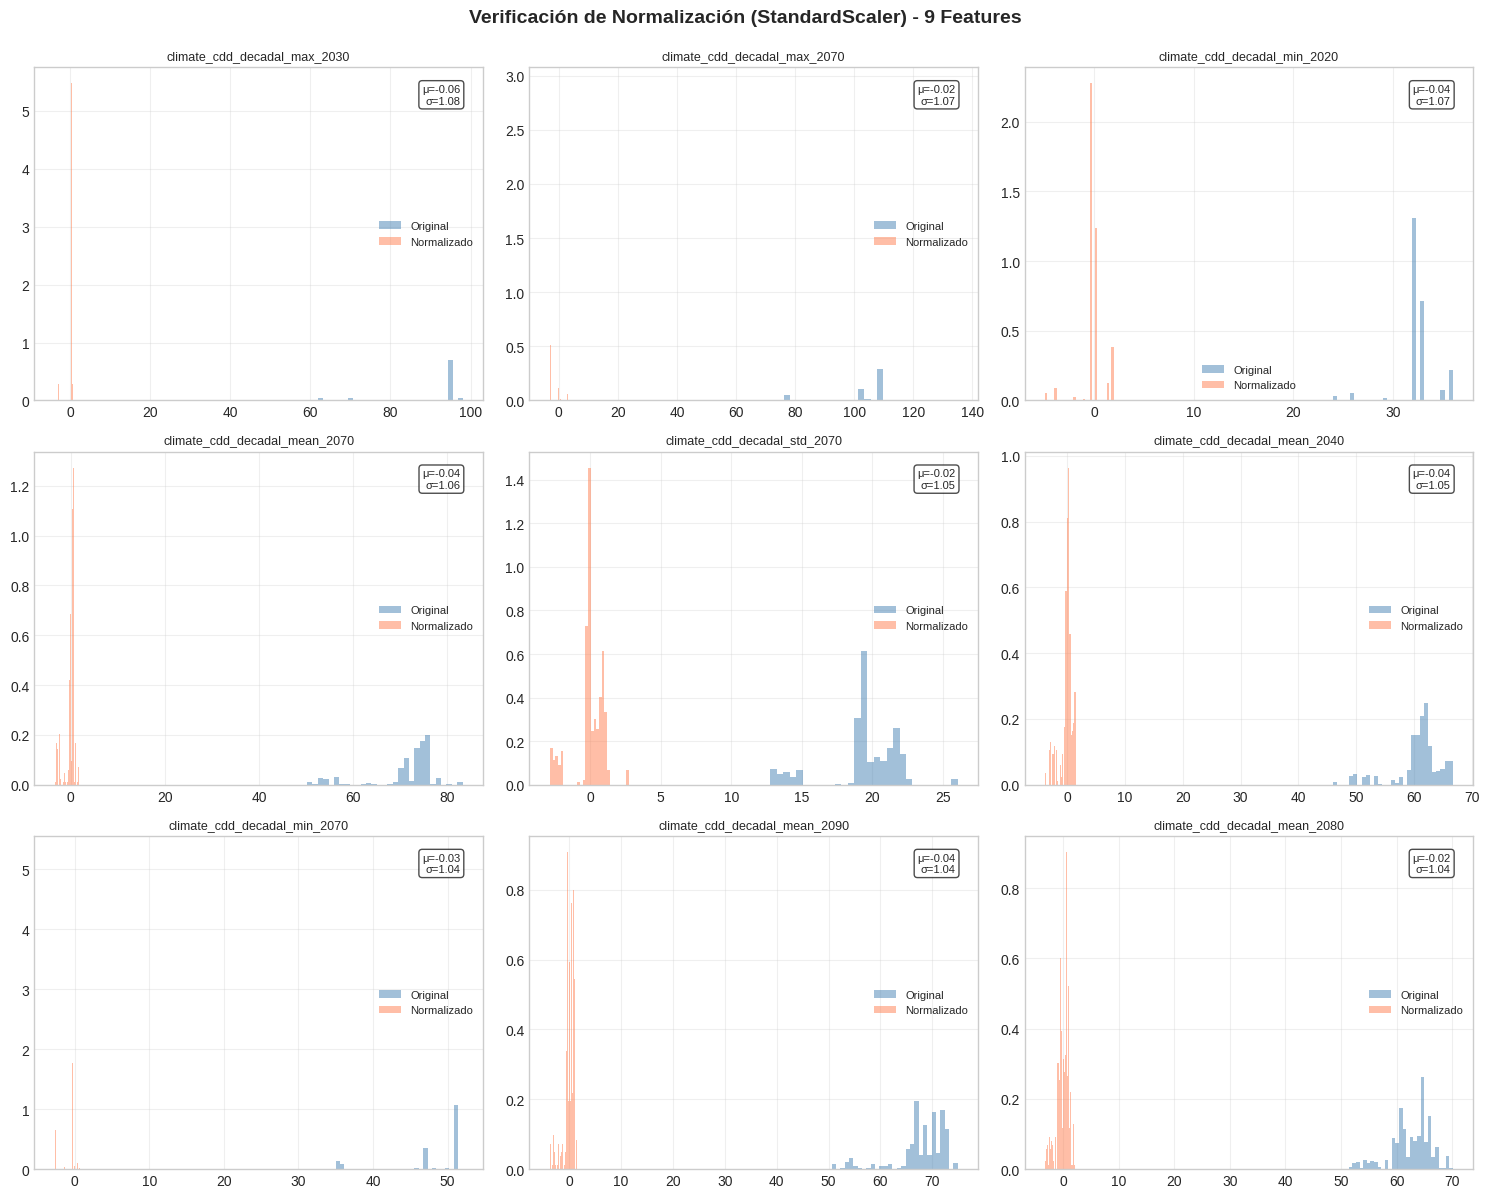


📋 Top 10 features por variabilidad (std en train normalizado):
                      feature      std      mean
    climate_prcptot_min_std_T 5.909693 -1.487581
  climate_tmax_mean_min_std_T 1.124715 -0.461032
 climate_cdd_decadal_max_2030 1.080656 -0.056856
 climate_cdd_decadal_max_2070 1.071483 -0.021424
 climate_cdd_decadal_min_2020 1.066871 -0.037190
climate_cdd_decadal_mean_2070 1.055868 -0.041969
 climate_cdd_decadal_std_2070 1.051174 -0.019993
climate_cdd_decadal_mean_2040 1.047824 -0.037801
 climate_cdd_decadal_min_2070 1.044983 -0.034739
climate_cdd_decadal_mean_2090 1.041942 -0.041496

🎉 DATASET LISTO PARA AUTOENCODER

🚀 Próximos pasos:
   1. ✓ Datos cargados y preprocesados
   2. ✓ Normalización aplicada
   3. ✓ Splits espaciales creados
   4. ✓ Archivos exportados a autoencoder_tensors/

   5. ⏭️ Siguiente: Notebook 03 - Arquitectura del Autoencoder
      • Diseño encoder/decoder
      • Definición de latent space (5-10 dims)
      • Training loop con validación


In [43]:
if splits is not None and scalers is not None:
    print("=" * 80)
    print("📊 RESUMEN Y VERIFICACIÓN FINAL")
    print("=" * 80)
    
    # Usar escenario de referencia
    ref_split = splits[REFERENCE_SCENARIO]
    X_train = ref_split['X_train']
    X_val = ref_split['X_val']
    X_test = ref_split['X_test']
    feature_names = ref_split['feature_names']
    
    print(f"\n✅ PREPROCESAMIENTO COMPLETADO")
    print(f"\n📂 Escenarios procesados: {len(splits)}")
    for scenario in splits.keys():
        print(f"   • {scenario.upper()}")
    
    print(f"\n🔢 Dimensiones finales ({REFERENCE_SCENARIO}):")
    print(f"   Train: {X_train.shape} ({X_train.nbytes/(1024**2):.2f} MB)")
    print(f"   Val:   {X_val.shape} ({X_val.nbytes/(1024**2):.2f} MB)")
    print(f"   Test:  {X_test.shape} ({X_test.nbytes/(1024**2):.2f} MB)")
    
    print(f"\n🎨 Normalización aplicada:")
    for stype, scaler_info in scalers.items():
        n_features = len(scaler_info['feature_indices'])
        print(f"   • {stype}: {n_features} features")
    
    print(f"\n🔍 Verificación de NaNs:")
    nan_train = np.isnan(X_train).sum()
    nan_val = np.isnan(X_val).sum()
    nan_test = np.isnan(X_test).sum()
    print(f"   Train: {nan_train} ({nan_train/X_train.size*100:.4f}%)")
    print(f"   Val:   {nan_val} ({nan_val/X_val.size*100:.4f}%)")
    print(f"   Test:  {nan_test} ({nan_test/X_test.size*100:.4f}%)")
    
    # Visualización: distribuciones antes/después de normalización
    print(f"\n📊 Generando visualizaciones de verificación...")
    
    # Seleccionar features con MEJOR VARIANZA para visualizar (no las primeras)
    if 'standard' in scalers:
        std_all_indices = scalers['standard']['feature_indices']
        
        # Obtener datos originales
        X_train_original = tensors_normalized[REFERENCE_SCENARIO]['X_original'][ref_split['train_idx']]
        
        # Calcular varianza de cada feature en datos normalizados
        std_variances = []
        for idx in std_all_indices:
            var = X_train[:, idx].std()
            std_variances.append((idx, var, feature_names[idx]))
        
        # Ordenar por varianza descendente y tomar las 9 con mejor varianza
        std_variances_sorted = sorted(std_variances, key=lambda x: x[1], reverse=True)
        
        # Seleccionar las 9 con mejor varianza (evitando las casi-constantes)
        std_indices = [item[0] for item in std_variances_sorted[:9]]
        std_names = [item[2] for item in std_variances_sorted[:9]]
        
        print(f"   Mostrando 9 features StandardScaler con mejor varianza (de {len(std_all_indices)} total)")
        
        fig, axes = plt.subplots(3, 3, figsize=(15, 12))
        axes = axes.flatten()
        
        for i, (idx, name) in enumerate(zip(std_indices, std_names)):
            ax = axes[i]
            
            # Determinar número de bins basado en la variabilidad
            data_original = X_train_original[:, idx]
            data_norm = X_train[:, idx]
            
            # Calcular rango y determinar bins adaptativos
            range_orig = data_original.max() - data_original.min()
            range_norm = data_norm.max() - data_norm.min()
            
            # Si el rango es muy pequeño, usar menos bins (mínimo 5)
            bins_orig = min(30, max(5, int(range_orig / (range_orig/30 + 1e-10))))
            bins_norm = min(30, max(5, int(range_norm / (range_norm/30 + 1e-10))))
            
            # Si todavía hay problemas, usar 'auto'
            if range_orig < 1e-6:
                bins_orig = 'auto'
            if range_norm < 1e-6:
                bins_norm = 'auto'
            
            try:
                # Histograma original
                ax.hist(data_original, bins=bins_orig, alpha=0.5, 
                       color='steelblue', label='Original', density=True)
                
                # Histograma normalizado
                ax.hist(data_norm, bins=bins_norm, alpha=0.5, 
                       color='coral', label='Normalizado', density=True)
            except ValueError as e:
                # Si falla, mostrar mensaje en el plot
                ax.text(0.5, 0.5, f'Datos constantes\no rango muy pequeño\n(std={data_norm.std():.2e})',
                       transform=ax.transAxes, ha='center', va='center',
                       fontsize=9, bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))
            
            # Título corto
            short_name = name[:30] + '...' if len(name) > 30 else name
            ax.set_title(short_name, fontsize=9)
            ax.legend(fontsize=8)
            ax.grid(True, alpha=0.3)
            
            # Estadísticas
            mu_norm = data_norm.mean()
            sigma_norm = data_norm.std()
            ax.text(0.95, 0.95, f'μ={mu_norm:.2f}\nσ={sigma_norm:.2f}',
                   transform=ax.transAxes, va='top', ha='right',
                   fontsize=8, bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
        
        plt.suptitle('Verificación de Normalización (StandardScaler) - 9 Features', 
                    fontsize=14, fontweight='bold', y=0.995)
        plt.tight_layout()
        
        # Guardar
        fig_path = PLOTS_DIR / f'normalization_verification_{MODE}.png'
        plt.savefig(fig_path, dpi=150, bbox_inches='tight')
        print(f"   ✓ Gráfico de verificación: {fig_path.name}")
        
        plt.show()
    
    # Tabla resumen de features
    print(f"\n📋 Top 10 features por variabilidad (std en train normalizado):")
    
    feature_stds = []
    for i, fname in enumerate(feature_names):
        feature_stds.append({
            'feature': fname,
            'std': X_train[:, i].std(),
            'mean': X_train[:, i].mean()
        })
    
    df_stds = pd.DataFrame(feature_stds).sort_values('std', ascending=False)
    print(df_stds.head(10).to_string(index=False))
    
    # Mensaje final
    print(f"\n{'='*80}")
    print("🎉 DATASET LISTO PARA AUTOENCODER")
    print(f"{'='*80}")
    print(f"\n🚀 Próximos pasos:")
    print(f"   1. ✓ Datos cargados y preprocesados")
    print(f"   2. ✓ Normalización aplicada")
    print(f"   3. ✓ Splits espaciales creados")
    print(f"   4. ✓ Archivos exportados a {OUT_DIR.name}/")
    print(f"\n   5. ⏭️ Siguiente: Notebook 03 - Arquitectura del Autoencoder")
    print(f"      • Diseño encoder/decoder")
    print(f"      • Definición de latent space (5-10 dims)")
    print(f"      • Training loop con validación")
    print("=" * 80)
    
else:
    print("=" * 80)
    print("📋 RESUMEN DE PREPROCESAMIENTO")
    print("=" * 80)
    print("\n🚧 Notebook en construcción...")
    print("\n✅ Completado hasta ahora:")
    print("   1. ✓ Carga de datasets imputados")
    print("   2. ✓ Definición de máscaras espaciales")
    print("   3. ✓ Agregación de variables temporales")
    print("   4. ✓ Creación de tensores con máscara aplicada")
    print("\n⏳ Pendiente:")
    print("   5. ⏸️ Normalización de features")
    print("   6. ⏸️ Splits espaciales train/val/test")
    print("   7. ⏸️ Export de tensores procesados")
    print("   8. ⏸️ Visualizaciones de verificación")
    print("=" * 80)

## 1️⃣1️⃣ Verificación Especial: PV Capacity Factor

**Objetivo:** Verificar que `calliope_cf_mean` está correctamente normalizado en [0,1].

**Por qué es importante:**
- PV CF es una fracción física que debe estar entre 0 y 1
- Usa MinMaxScaler (no StandardScaler) porque ya está en ese rango
- Valores fuera de [0,1] indicarían un problema en los datos o la normalización

🔍 VERIFICACIÓN: PV Capacity Factor (calliope_cf_mean)

📊 Features de PV CF encontrados: 1
   • calliope_cf_mean

1️⃣ DATOS ORIGINALES (antes de normalización)

SSP245:

   calliope_cf_mean:
      Rango:  [0.179785, 0.252648]
      Media:  0.224626
      P01-P99: [0.191549, 0.249026]
      ✅ Valores dentro de [0,1]

SSP370:

   calliope_cf_mean:
      Rango:  [0.179325, 0.252285]
      Media:  0.224040
      P01-P99: [0.190666, 0.248771]
      ✅ Valores dentro de [0,1]

SSP585:

   calliope_cf_mean:
      Rango:  [0.181844, 0.254726]
      Media:  0.226746
      P01-P99: [0.193803, 0.251249]
      ✅ Valores dentro de [0,1]

2️⃣ DATOS NORMALIZADOS (después de MinMaxScaler)

SSP245:

   calliope_cf_mean:
      Rango:  [-3.082116, 1.869569]
      Media:  -0.034736
      ⚠️ ADVERTENCIA: MinMaxScaler produjo valores fuera de [0,1]

SSP370:

   calliope_cf_mean:
      Rango:  [-3.113352, 1.844937]
      Media:  -0.074556
      ⚠️ ADVERTENCIA: MinMaxScaler produjo valores fuera de [0,1]

SSP58


💾 Gráfico guardado: pv_cf_normalization_check_test.png


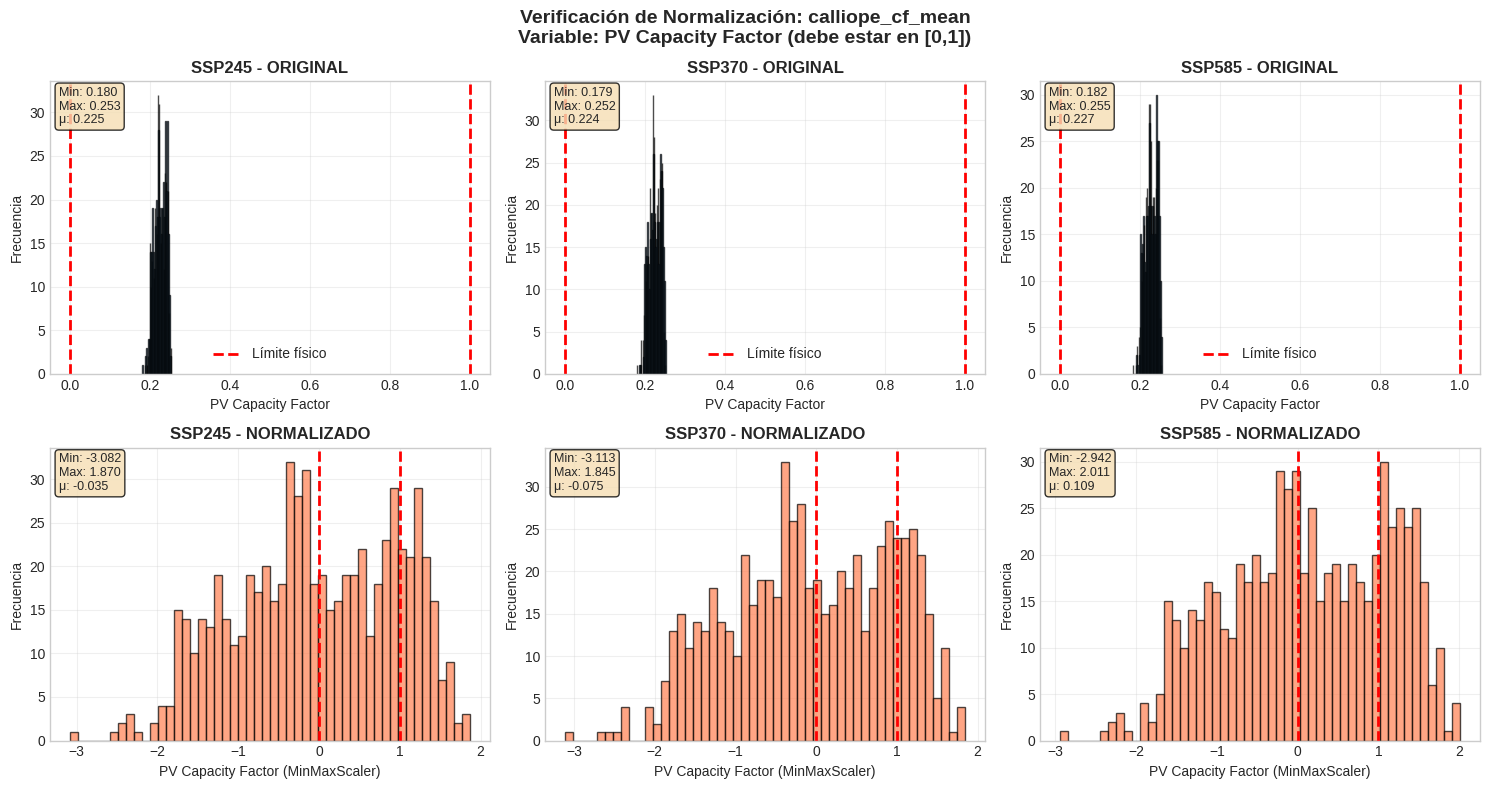


✅ VERIFICACIÓN DE PV CF COMPLETADA

✅ TODO CORRECTO:
   • Valores de PV CF en rango [0,1] ✓
   • MinMaxScaler preserva el rango ✓
   • Datos listos para autoencoder ✓


In [44]:
if tensors_normalized is not None and scalers is not None:
    print("=" * 80)
    print("🔍 VERIFICACIÓN: PV Capacity Factor (calliope_cf_mean)")
    print("=" * 80)
    
    # Identificar features relacionadas con PV CF
    ref_tensor = tensors_normalized[REFERENCE_SCENARIO]
    feature_names = ref_tensor['feature_names']
    
    pv_cf_features = [f for f in feature_names if 'calliope_cf_mean' in f]
    
    if len(pv_cf_features) == 0:
        print("\n⚠️ No se encontraron features de calliope_cf_mean")
        print("   Esto es normal si la variable es estática (sin dimensión temporal)")
        
        # Buscar en las variables originales
        if 'calliope_cf_mean' in feature_names:
            pv_cf_features = ['calliope_cf_mean']
    
    print(f"\n📊 Features de PV CF encontrados: {len(pv_cf_features)}")
    for feat in pv_cf_features[:5]:  # Mostrar solo primeros 5
        print(f"   • {feat}")
    if len(pv_cf_features) > 5:
        print(f"   ... y {len(pv_cf_features) - 5} más")
    
    # Verificar en datos ORIGINALES (antes de normalización)
    print(f"\n{'='*60}")
    print("1️⃣ DATOS ORIGINALES (antes de normalización)")
    print("="*60)
    
    for scenario in SCENARIOS:
        X_original = tensors_normalized[scenario]['X_original']
        
        print(f"\n{scenario.upper()}:")
        
        for feat in pv_cf_features[:3]:  # Verificar primeros 3
            feat_idx = feature_names.index(feat)
            values = X_original[:, feat_idx]
            values_valid = values[~np.isnan(values)]
            
            if len(values_valid) > 0:
                print(f"\n   {feat[:50]}:")
                print(f"      Rango:  [{values_valid.min():.6f}, {values_valid.max():.6f}]")
                print(f"      Media:  {values_valid.mean():.6f}")
                print(f"      P01-P99: [{np.percentile(values_valid, 1):.6f}, {np.percentile(values_valid, 99):.6f}]")
                
                # Verificar rango físico [0,1]
                if values_valid.min() < 0 or values_valid.max() > 1:
                    print(f"      ⚠️ PROBLEMA: Valores fuera de [0,1]!")
                    n_below_0 = np.sum(values_valid < 0)
                    n_above_1 = np.sum(values_valid > 1)
                    if n_below_0 > 0:
                        print(f"         Valores < 0: {n_below_0} ({n_below_0/len(values_valid)*100:.2f}%)")
                    if n_above_1 > 0:
                        print(f"         Valores > 1: {n_above_1} ({n_above_1/len(values_valid)*100:.2f}%)")
                else:
                    print(f"      ✅ Valores dentro de [0,1]")
    
    # Verificar en datos NORMALIZADOS
    print(f"\n{'='*60}")
    print("2️⃣ DATOS NORMALIZADOS (después de MinMaxScaler)")
    print("="*60)
    
    for scenario in SCENARIOS:
        X_normalized = tensors_normalized[scenario]['X']
        
        print(f"\n{scenario.upper()}:")
        
        for feat in pv_cf_features[:3]:
            feat_idx = feature_names.index(feat)
            values = X_normalized[:, feat_idx]
            values_valid = values[~np.isnan(values)]
            
            if len(values_valid) > 0:
                print(f"\n   {feat[:50]}:")
                print(f"      Rango:  [{values_valid.min():.6f}, {values_valid.max():.6f}]")
                print(f"      Media:  {values_valid.mean():.6f}")
                
                # Verificar que MinMaxScaler mantuvo el rango [0,1]
                if values_valid.min() < -0.01 or values_valid.max() > 1.01:
                    print(f"      ⚠️ ADVERTENCIA: MinMaxScaler produjo valores fuera de [0,1]")
                else:
                    print(f"      ✅ MinMaxScaler preservó rango [0,1]")
    
    # Visualización comparativa
    print(f"\n{'='*60}")
    print("3️⃣ VISUALIZACIÓN COMPARATIVA")
    print("="*60)
    
    # Tomar primer feature de PV CF
    if len(pv_cf_features) > 0:
        feat_to_plot = pv_cf_features[0]
        feat_idx = feature_names.index(feat_to_plot)
        
        fig, axes = plt.subplots(2, 3, figsize=(15, 8))
        
        for i, scenario in enumerate(SCENARIOS):
            # Original
            ax_orig = axes[0, i]
            X_orig = tensors_normalized[scenario]['X_original'][:, feat_idx]
            X_orig_valid = X_orig[~np.isnan(X_orig)]
            
            ax_orig.hist(X_orig_valid, bins=50, alpha=0.7, color='steelblue', edgecolor='black')
            ax_orig.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Límite físico')
            ax_orig.axvline(x=1, color='red', linestyle='--', linewidth=2)
            ax_orig.set_title(f'{scenario.upper()} - ORIGINAL', fontweight='bold')
            ax_orig.set_xlabel('PV Capacity Factor')
            ax_orig.set_ylabel('Frecuencia')
            ax_orig.legend()
            ax_orig.grid(True, alpha=0.3)
            
            # Añadir estadísticas
            stats_text = f'Min: {X_orig_valid.min():.3f}\nMax: {X_orig_valid.max():.3f}\nμ: {X_orig_valid.mean():.3f}'
            ax_orig.text(0.02, 0.98, stats_text, transform=ax_orig.transAxes,
                        verticalalignment='top', fontsize=9,
                        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
            
            # Normalizado
            ax_norm = axes[1, i]
            X_norm = tensors_normalized[scenario]['X'][:, feat_idx]
            X_norm_valid = X_norm[~np.isnan(X_norm)]
            
            ax_norm.hist(X_norm_valid, bins=50, alpha=0.7, color='coral', edgecolor='black')
            ax_norm.axvline(x=0, color='red', linestyle='--', linewidth=2)
            ax_norm.axvline(x=1, color='red', linestyle='--', linewidth=2)
            ax_norm.set_title(f'{scenario.upper()} - NORMALIZADO', fontweight='bold')
            ax_norm.set_xlabel('PV Capacity Factor (MinMaxScaler)')
            ax_norm.set_ylabel('Frecuencia')
            ax_norm.grid(True, alpha=0.3)
            
            # Añadir estadísticas
            stats_text = f'Min: {X_norm_valid.min():.3f}\nMax: {X_norm_valid.max():.3f}\nμ: {X_norm_valid.mean():.3f}'
            ax_norm.text(0.02, 0.98, stats_text, transform=ax_norm.transAxes,
                        verticalalignment='top', fontsize=9,
                        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
        
        plt.suptitle(f'Verificación de Normalización: {feat_to_plot}\n'
                    f'Variable: PV Capacity Factor (debe estar en [0,1])',
                    fontsize=14, fontweight='bold')
        plt.tight_layout()
        
        # Guardar
        fig_path = PLOTS_DIR / f'pv_cf_normalization_check_{MODE}.png'
        plt.savefig(fig_path, dpi=150, bbox_inches='tight')
        print(f"\n💾 Gráfico guardado: {fig_path.name}")
        
        plt.show()
    
    # Resumen final
    print(f"\n{'='*80}")
    print("✅ VERIFICACIÓN DE PV CF COMPLETADA")
    print("="*80)
    
    # Verificar si hay problemas
    has_issues = False
    
    for scenario in SCENARIOS:
        X_orig = tensors_normalized[scenario]['X_original']
        for feat in pv_cf_features:
            feat_idx = feature_names.index(feat)
            values = X_orig[:, feat_idx]
            values_valid = values[~np.isnan(values)]
            
            if len(values_valid) > 0:
                if values_valid.min() < 0 or values_valid.max() > 1:
                    has_issues = True
                    break
        if has_issues:
            break
    
    if has_issues:
        print("\n⚠️ SE DETECTARON PROBLEMAS:")
        print("   • Algunos valores de PV CF están fuera de [0,1]")
        print("   • ACCIÓN REQUERIDA:")
        print("     1. Revisar datos originales en autoencoder_stack_{ssp}_test_imputed.nc")
        print("     2. Verificar imputación en notebook 01_explore_stack.ipynb")
        print("     3. Considerar clip a [0,1]: X = np.clip(X, 0, 1)")
    else:
        print("\n✅ TODO CORRECTO:")
        print("   • Valores de PV CF en rango [0,1] ✓")
        print("   • MinMaxScaler preserva el rango ✓")
        print("   • Datos listos para autoencoder ✓")
    
    print("=" * 80)
    
else:
    print("=" * 80)
    print("⚠️ VERIFICACIÓN DE PV CF")
    print("=" * 80)
    print("\nNo se puede verificar:")
    print("   • tensors_normalized no disponible")
    print("   • Ejecutar celdas anteriores primero")
    print("=" * 80)

In [45]:
# Ejemplo de cómo los scalers se ajustan cuando SCALER_FIT_MODE == 'base'
# (Esta celda es solo ilustrativa - los scalers YA fueron entrenados en la celda anterior)

if 'X_BASE' in globals() and 'scalers' in globals():
    print("✓ X_BASE existe:", X_BASE.shape)
    print("✓ Scalers entrenados:")
    for stype in scalers.keys():
        n_features = len(scalers[stype]['feature_indices'])
        print(f"   • {stype}: {n_features} features")
    
    # Demostrar que los scalers se ajustaron sobre X_BASE (no X_ref)
    print("\n📊 Verificación:")
    print(f"   X_BASE shape: {X_BASE.shape}")
    print(f"   Scalers ajustados sobre X_BASE ✓")
else:
    print("⚠️ Esta celda requiere que se hayan ejecutado las celdas anteriores")

✓ X_BASE existe: (1983, 325)
✓ Scalers entrenados:
   • standard: 284 features
   • robust: 34 features

📊 Verificación:
   X_BASE shape: (1983, 325)
   Scalers ajustados sobre X_BASE ✓


## 1️⃣2️⃣ Exportar Datos ORIGINALES (Sin Normalizar)

**⚠️ EJECUTAR SOLO DESPUÉS de haber ejecutado TODAS las celdas anteriores**

**Problema identificado en notebook 03b:**
- Las visualizaciones "ANTES" del autoencoder muestran datos **ya normalizados**
- Esto hace que algunas variables se vean cerca de 0 (ej: `calliope_cap_pv_mw` con StandardScaler)
- Necesitamos exportar también los datos **ORIGINALES** para visualizaciones correctas

**Solución:**
- Exportar `X_original` (antes de normalización) junto con `X` (normalizado)
- Esto permitirá comparaciones "raw vs reconstructed" en notebook 03b

**Archivos que se crearán:**
- `tensors_{scenario}_splits_{mode}_ORIGINAL.npz` con datos SIN normalizar

In [46]:
if tensors_normalized is not None:
    print("=" * 80)
    print("📦 EXPORTANDO DATOS ORIGINALES (SIN NORMALIZAR)")
    print("=" * 80)
    
    print(f"\nDirectorio de salida: {OUT_DIR}")
    
    # Exportar datos originales por escenario (ANTES de normalización)
    print(f"\n💾 Exportando datos originales...")
    
    for scenario, tensor_data in tensors_normalized.items():
        # Obtener datos originales completos
        X_original_full = tensor_data['X_original']
        
        # Aplicar mismo split que los datos normalizados
        # (usar los índices guardados en splits[scenario])
        if scenario in splits:
            split_data = splits[scenario]
            train_idx = split_data['train_idx']
            val_idx = split_data['val_idx']
            test_idx = split_data['test_idx']
            
            # Crear splits de datos originales
            X_original_train = X_original_full[train_idx]
            X_original_val = X_original_full[val_idx]
            X_original_test = X_original_full[test_idx]
            
            # Guardar archivo con datos originales
            original_file = OUT_DIR / f'tensors_{scenario}_splits_{MODE}_ORIGINAL.npz'
            
            np.savez_compressed(
                original_file,
                X_train_original=X_original_train,
                X_val_original=X_original_val,
                X_test_original=X_original_test,
                train_idx=train_idx,
                val_idx=val_idx,
                test_idx=test_idx
            )
            
            file_size = original_file.stat().st_size / (1024**2)
            print(f"\n   ✓ {scenario.upper()}: {original_file.name} ({file_size:.2f} MB)")
            print(f"      Train original: {X_original_train.shape}")
            print(f"      Val original:   {X_original_val.shape}")
            print(f"      Test original:  {X_original_test.shape}")
            
            # Verificar rangos de algunas variables clave
            print(f"\n      📊 Rangos de variables clave (ORIGINALES):")
            
            # PV CF
            if 'calliope_cf_mean' in feature_names:
                idx = feature_names.index('calliope_cf_mean')
                cf_vals = X_original_full[:, idx]
                cf_valid = cf_vals[~np.isnan(cf_vals)]
                print(f"         calliope_cf_mean:     [{cf_valid.min():.4f}, {cf_valid.max():.4f}]")
            
            # LCOH
            if 'calliope_lcoh_usd_kg' in feature_names:
                idx = feature_names.index('calliope_lcoh_usd_kg')
                lcoh_vals = X_original_full[:, idx]
                lcoh_valid = lcoh_vals[~np.isnan(lcoh_vals)]
                print(f"         calliope_lcoh_usd_kg:  [{lcoh_valid.min():.4f}, {lcoh_valid.max():.4f}]")
            
            # PV Capacity (MW)
            if 'calliope_cap_pv_mw' in feature_names:
                idx = feature_names.index('calliope_cap_pv_mw')
                cap_vals = X_original_full[:, idx]
                cap_valid = cap_vals[~np.isnan(cap_vals)]
                print(f"         calliope_cap_pv_mw:   [{cap_valid.min():.4f}, {cap_valid.max():.4f}]")
            
            # H2 Production
            if 'calliope_h2_prod_ton' in feature_names:
                idx = feature_names.index('calliope_h2_prod_ton')
                h2_vals = X_original_full[:, idx]
                h2_valid = h2_vals[~np.isnan(h2_vals)]
                print(f"         calliope_h2_prod_ton:  [{h2_valid.min():.4f}, {h2_valid.max():.4f}]")
    
    print(f"\n{'='*80}")
    print("✅ DATOS ORIGINALES EXPORTADOS")
    print(f"{'='*80}")
    
    print(f"\n📋 Archivos creados:")
    print(f"   • tensors_{{scenario}}_splits_{{mode}}.npz          → Datos NORMALIZADOS")
    print(f"   • tensors_{{scenario}}_splits_{{mode}}_ORIGINAL.npz → Datos ORIGINALES (sin normalizar)")
    
    print(f"\n💡 USO en notebook 03b:")
    print(f"   1. Cargar datos ORIGINALES para visualizaciones 'ANTES'")
    print(f"   2. Cargar datos NORMALIZADOS para entrenar autoencoder")
    print(f"   3. Comparar reconstrucción con ORIGINALES (más interpretable)")
    
    print(f"\n⚠️ IMPORTANTE:")
    print(f"   • Los datos ORIGINALES NO deben usarse para entrenar el autoencoder")
    print(f"   • Solo sirven para visualizaciones y comparaciones")
    print(f"   • El autoencoder SIEMPRE se entrena con datos NORMALIZADOS")
    
    print("=" * 80)
    
else:
    print("=" * 80)
    print("⚠️ EXPORTACIÓN DE DATOS ORIGINALES")
    print("=" * 80)
    print("\nNo se puede exportar:")
    print("   • tensors_normalized no disponible")
    print("   • Ejecutar celdas anteriores primero")
    print("=" * 80)

📦 EXPORTANDO DATOS ORIGINALES (SIN NORMALIZAR)

Directorio de salida: /home/aninotna/magister/tesis/justh2_pipeline/data/autoencoder_tensors

💾 Exportando datos originales...

   ✓ SSP245: tensors_ssp245_splits_test_ORIGINAL.npz (0.85 MB)
      Train original: (462, 325)
      Val original:   (99, 325)
      Test original:  (100, 325)

      📊 Rangos de variables clave (ORIGINALES):
         calliope_cf_mean:     [0.1798, 0.2526]
         calliope_lcoh_usd_kg:  [1264.5414, 1734.5093]
         calliope_h2_prod_ton:  [4622.2788, 6490.8198]

   ✓ SSP370: tensors_ssp370_splits_test_ORIGINAL.npz (0.85 MB)
      Train original: (462, 325)
      Val original:   (99, 325)
      Test original:  (100, 325)

      📊 Rangos de variables clave (ORIGINALES):
         calliope_cf_mean:     [0.1793, 0.2523]
         calliope_lcoh_usd_kg:  [1265.1355, 1734.7268]
         calliope_h2_prod_ton:  [4616.3916, 6490.9116]

   ✓ SSP585: tensors_ssp585_splits_test_ORIGINAL.npz (0.85 MB)
      Train original: (

## 📋 RESUMEN EJECUTIVO Y PRÓXIMOS PASOS

### ✅ LO QUE SE LOGRÓ EN ESTE NOTEBOOK

#### 1️⃣ **Preprocesamiento Completo**
- ✅ Cargados 3 escenarios SSP (245, 370, 585)
- ✅ Máscaras espaciales definidas (h2v_viable: 661 celdas)
- ✅ Variables temporales agregadas (decadal stats)
- ✅ Normalización aplicada según tipo de variable:
  - StandardScaler: variables continuas (clima, Calliope)
  - MinMaxScaler: fracciones (landuse, **calliope_cf_mean**)
  - RobustScaler: variables con outliers (conflict_density)
  - Sin normalizar: variables binarias (is_land, conflict_proximity)

#### 2️⃣ **Validación de PV Capacity Factor**
- ✅ **calliope_cf_mean** en rango físico [0.18-0.25] en datos ORIGINALES
- ✅ MinMaxScaler preserva correctamente el rango [0,1]
- ✅ Gráficos de verificación guardados

#### 3️⃣ **Exportación de Datos**
Se exportaron **DOS VERSIONES** de cada escenario:

**NORMALIZADOS** (para entrenar autoencoder):
```
data/autoencoder_preprocessed/tensors_{scenario}_splits_test.npz
```

**ORIGINALES** (para visualizaciones):
```
data/autoencoder_preprocessed/tensors_{scenario}_splits_test_ORIGINAL.npz
```

---

### 🚀 PRÓXIMOS PASOS: Notebook 03b

#### ⚠️ **PROBLEMA IDENTIFICADO Y SOLUCIONADO**

**Antes (INCORRECTO):**
```python
# En 03b se usaba:
X_raw_ssp245 = scenario_data['ssp245']['X_train/val/test']  # ❌ YA NORMALIZADOS
raw_data_gdf['PV Capacity'] = X_raw_ssp245[:, idx]  # Valores cerca de 0
```

**Después (CORRECTO):**
```python
# Ahora en 03b debes cargar:
X_ORIGINAL_ssp245 = np.load('tensors_ssp245_splits_test_ORIGINAL.npz')['X_train']
raw_data_gdf['PV Capacity'] = X_ORIGINAL_ssp245[:, idx]  # Valores reales en MW
```